#1.0 Data Initalization

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from collections import defaultdict


In [ ]:
drive.mount('/content/drive')

# define file paths
individual_csv_path = "/content/drive/My Drive/Colab Notebooks/MIE304/MIE304 Project/Data/New Sour Patch Individual.csv"
bag_csv_path = "/content/drive/My Drive/Colab Notebooks/MIE304/MIE304 Project/Data/Sour Patch Bag Data.csv"

Mounted at /content/drive


In [ ]:
# read CSV files
df_individual = pd.read_csv(individual_csv_path)
df_bag = pd.read_csv(bag_csv_path)

# display first few rows
print("Individual Sour Patch Data:")
print(df_individual.head())

print("\nSour Patch Bag Data:")
print(df_bag.head())

Individual Sour Patch Data:
   Sample  Bag Number   Color  Weight (grams)  Length (cm)  Deformity Notes
0       1           1    Blue               3         2.70      False   NaN
1       2           1    Blue               3         2.95      False   NaN
2       3           1     red               3         3.00      False   NaN
3       4           1  orange               4         3.20      False   NaN
4       5           1     red               3         3.05      False   NaN

Sour Patch Bag Data:
   Bag Number   Name                                 Address   Retailer  \
0           1  Eylul  63 Front Street E, Toronto, ON M5E 1B3     Rexall   
1           2  Eylul  63 Front Street E, Toronto, ON M5E 1B3     Rexall   
2           3  Grace     360A Bloor St W, Toronto, ONM5S 1X1   Shoppers   
3           4  Grace     360A Bloor St W, Toronto, ONM5S 1X1   Shoppers   
4           5  Helen   6464 Yonge St, North York, ON M2M 3X4  Dollarama   

   Weight (g)  Expected Weight (g)  Empty B

#2.0 Data Cleaning

In [ ]:
df_bag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Bag Number            6 non-null      int64 
 1   Name                  6 non-null      object
 2   Address               6 non-null      object
 3   Retailer              6 non-null      object
 4   Weight (g)            6 non-null      int64 
 5   Expected Weight (g)   6 non-null      int64 
 6   Empty Bag Weight (g)  6 non-null      int64 
dtypes: int64(4), object(3)
memory usage: 468.0+ bytes


In [ ]:
df_bag.describe()

,Bag Number,Weight (g),Expected Weight (g),Empty Bag Weight (g)
count,6.000000,6.000000,6.0,6.000000
mean,3.500000,152.833333,150.0,3.166667
std,1.870829,3.970726,0.0,0.752773
min,1.000000,147.000000,150.0,2.000000
25%,2.250000,150.000000,150.0,3.000000
50%,3.500000,154.500000,150.0,3.000000
75%,4.750000,156.000000,150.0,3.750000
max,6.000000,156.000000,150.0,4.000000


In [ ]:
df_individual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sample          348 non-null    int64  
 1   Bag Number      348 non-null    int64  
 2   Color           348 non-null    object 
 3   Weight (grams)  348 non-null    int64  
 4   Length (cm)     348 non-null    float64
 5   Deformity       348 non-null    bool   
 6   Notes           19 non-null     object 
dtypes: bool(1), float64(1), int64(3), object(2)
memory usage: 16.8+ KB


In [ ]:
df_individual.describe()

,Sample,Bag Number,Weight (grams),Length (cm)
count,348.000000,348.000000,348.000000,348.000000
mean,29.520115,3.520115,2.704023,2.984626
std,16.798935,1.716893,0.640862,0.152598
min,1.000000,1.000000,1.000000,2.500000
25%,15.000000,2.000000,2.000000,2.900000
50%,29.500000,4.000000,3.000000,3.000000
75%,44.000000,5.000000,3.000000,3.050000
max,59.000000,6.000000,10.000000,4.500000


In [ ]:
# convert all values in the 'Color' column to lowercase
df_individual['Color'] = df_individual['Color'].str.lower()

# verify the change
print(df_individual['Color'].unique())

['blue' 'red' 'orange' 'yellow' 'green']


#3.0 Exploratory Data Analysis EDA

In [ ]:
df_individual.head()

,Sample,Bag Number,Color,Weight (grams),Length (cm),Deformity,Notes
0,1,1,blue,3,2.70,False,NaN
1,2,1,blue,3,2.95,False,NaN
2,3,1,red,3,3.00,False,NaN
3,4,1,orange,4,3.20,False,NaN
4,5,1,red,3,3.05,False,NaN


In [ ]:
# value counts for categorical columns
print(df_individual['Color'].value_counts())
print(df_individual['Deformity'].value_counts())

Color
red       102
blue       79
green      63
orange     62
yellow     42
Name: count, dtype: int64
Deformity
False    329
True      19
Name: count, dtype: int64


<ipython-input-11-b66899be2c6c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Color', data=df_individual, order=color_order, palette=color_palette)


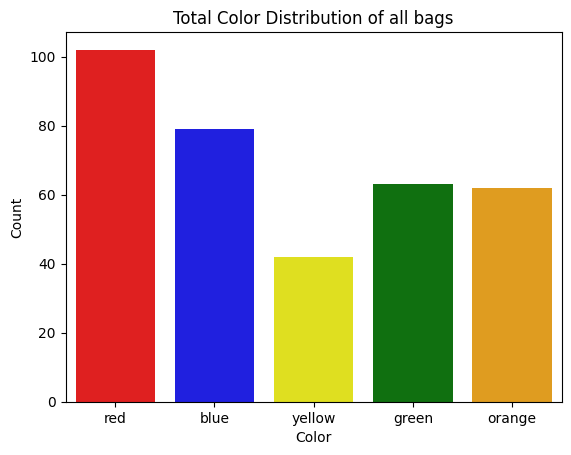

In [ ]:
# define the order of colors you want to use (make sure it's in a consistent order)
color_order = ['red', 'blue', 'yellow', 'green', 'orange']

# create a palette that matches the colors for the bars
color_palette = {'red': 'red', 'blue': 'blue', 'yellow': 'yellow', 'green': 'green', 'orange':'orange'}

# plotting the total distribution of 'Color'
sns.countplot(x='Color', data=df_individual, order=color_order, palette=color_palette)
plt.title('Total Color Distribution of all bags')
plt.xlabel('Color')
plt.ylabel('Count')
plt.show()

<ipython-input-12-74bad20037e9>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Color', data=bag_data, ax=axes[i], order=color_order, palette=color_palette)
<ipython-input-12-74bad20037e9>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Color', data=bag_data, ax=axes[i], order=color_order, palette=color_palette)
<ipython-input-12-74bad20037e9>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Color', data=bag_data, ax=axes[i], order=color_order, palette=color_palette)
<ipython-input-12-74bad20037e9>:14: FutureWarning: 

Pa

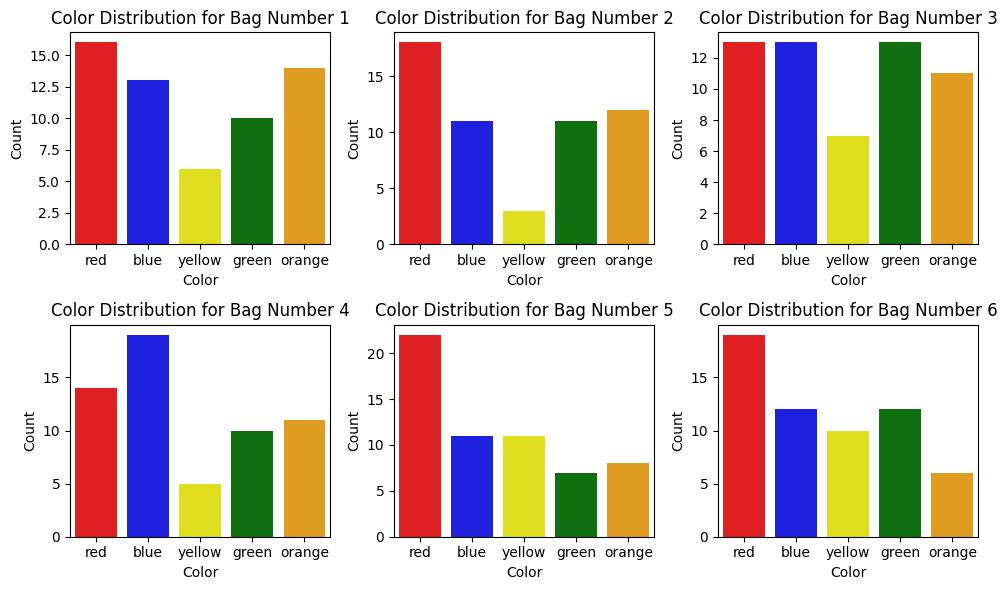

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))  # 2 rows, 3 columns

axes = axes.flatten()

# loop through each 'Bag Number' (1 through 6)
for i, bag_num in enumerate(range(1, 7)):
    # filter the data for the current bag number
    bag_data = df_individual[df_individual['Bag Number'] == bag_num]

    # plot the color distribution for the current bag number with the specified color order and palette
    sns.countplot(x='Color', data=bag_data, ax=axes[i], order=color_order, palette=color_palette)

    # set a title for each subplot
    axes[i].set_title(f'Color Distribution for Bag Number {bag_num}')
    axes[i].set_xlabel('Color')
    axes[i].set_ylabel('Count')

# adjust layout to make sure the plots fit
plt.tight_layout()
plt.show()

<ipython-input-13-fdf696ef1828>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Deformity', data=df_individual, palette=deformity_palette)


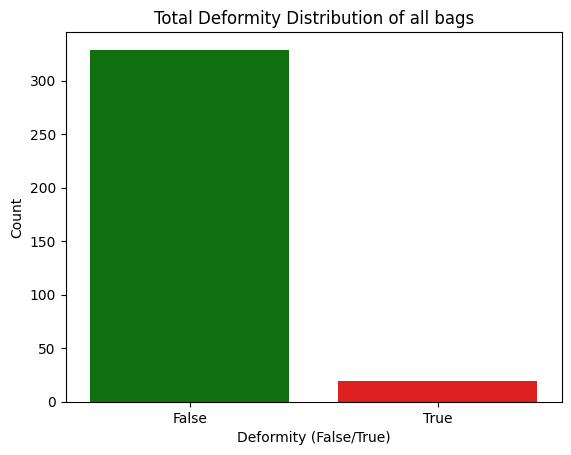

In [ ]:
# create a custom color palette where False is green and True is red
deformity_palette = {'False': 'green', 'True': 'red'}

# plotting the total deformity distribution
sns.countplot(x='Deformity', data=df_individual, palette=deformity_palette)
plt.title('Total Deformity Distribution of all bags')
plt.xlabel('Deformity (False/True)')
plt.ylabel('Count')
plt.show()

<ipython-input-14-d20cfd149f23>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Deformity', data=bag_data, ax=axes[i], palette=deformity_palette)
<ipython-input-14-d20cfd149f23>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Deformity', data=bag_data, ax=axes[i], palette=deformity_palette)
<ipython-input-14-d20cfd149f23>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Deformity', data=bag_data, ax=axes[i], palette=deformity_palette)
<ipython-input-14-d20cfd149f23>:14: FutureWarning: 

Passing `palette` without assigning

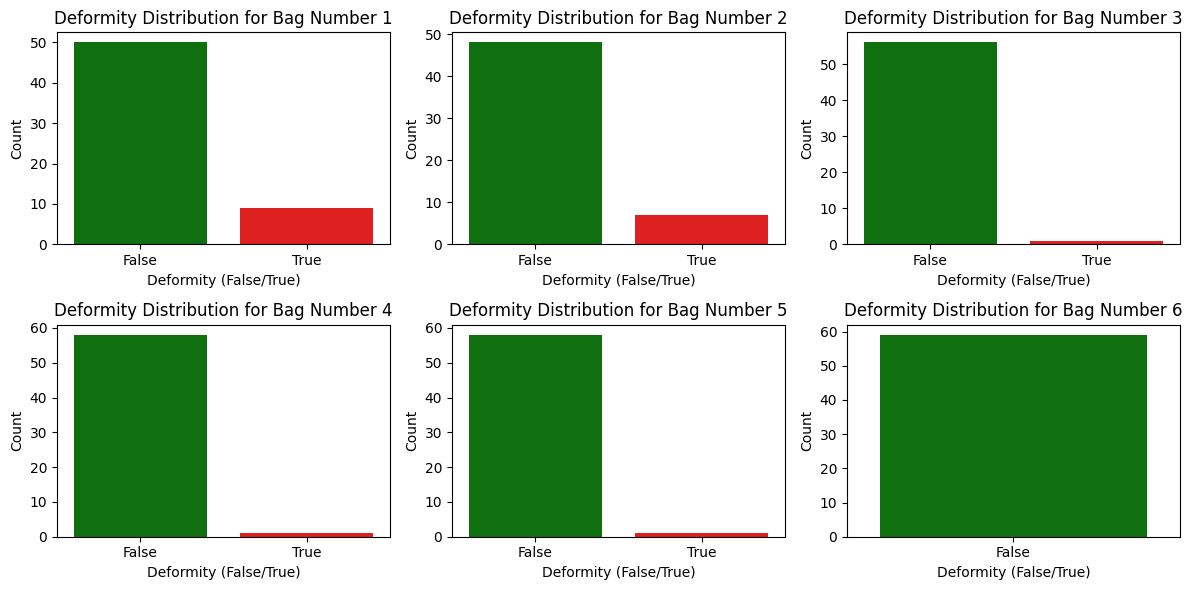

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))  # 2 rows, 3 columns

# flatten the axes array for easy iteration
axes = axes.flatten()

# loop through each 'Bag Number' (1 through 6)
for i, bag_num in enumerate(range(1, 7)):
    # filter the data for the current bag number
    bag_data = df_individual[df_individual['Bag Number'] == bag_num]

    # plot the deformity distribution for the current bag number
    sns.countplot(x='Deformity', data=bag_data, ax=axes[i], palette=deformity_palette)

    # set a title for each subplot
    axes[i].set_title(f'Deformity Distribution for Bag Number {bag_num}')
    axes[i].set_xlabel('Deformity (False/True)')
    axes[i].set_ylabel('Count')

# adjust layout to make sure the plots fit
plt.tight_layout()
plt.show()

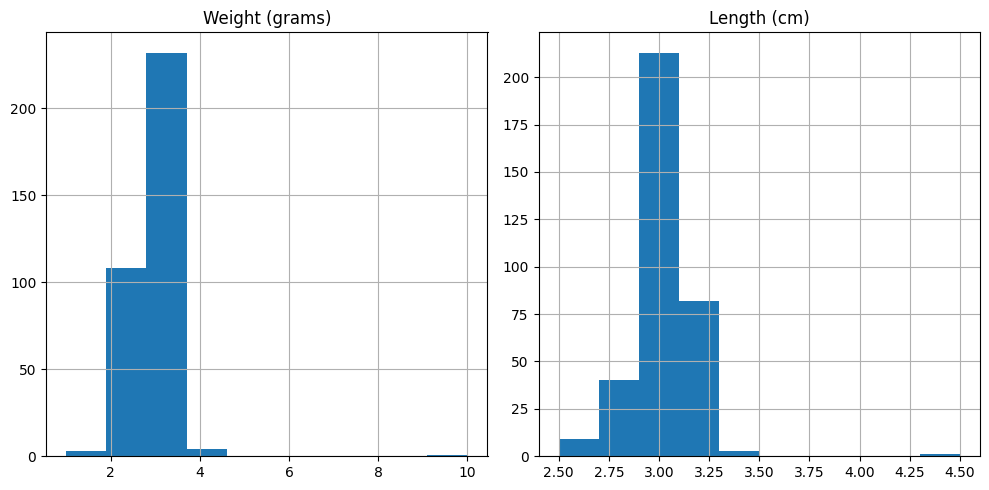

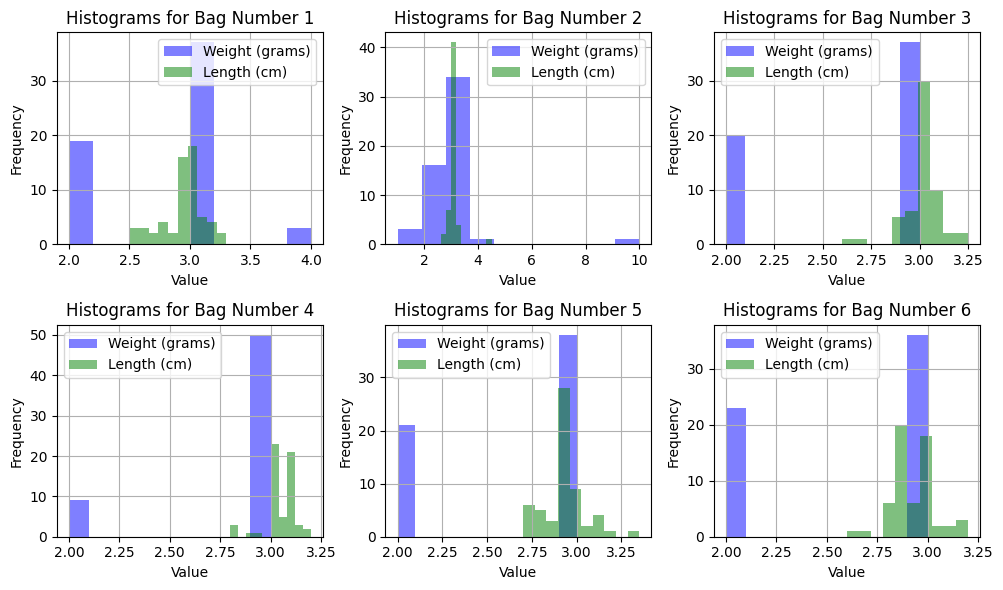

In [ ]:
# plot histograms for numerical features
df_individual[['Weight (grams)', 'Length (cm)']].hist(bins=10, figsize=(10, 5))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(10, 6))  # 2 rows, 3 columns

# flatten the axes array for easy iteration
axes = axes.flatten()

# loop through each 'Bag Number' (1 through 6)
for i, bag_num in enumerate(range(1, 7)):
    # filter the data for the current bag number
    bag_data = df_individual[df_individual['Bag Number'] == bag_num]

    # plot histograms for 'Weight (grams)' and 'Length (cm)' for each bag
    # create two histograms in the same subplot
    ax = axes[i]

    # plot 'Weight (grams)'
    bag_data['Weight (grams)'].hist(bins=10, alpha=0.5, label='Weight (grams)', ax=ax, color='blue')

    # plot 'Length (cm)'
    bag_data['Length (cm)'].hist(bins=10, alpha=0.5, label='Length (cm)', ax=ax, color='green')

    # set titles and labels
    ax.set_title(f'Histograms for Bag Number {bag_num}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

# adjust layout to make sure the plots fit
plt.tight_layout()
plt.show()

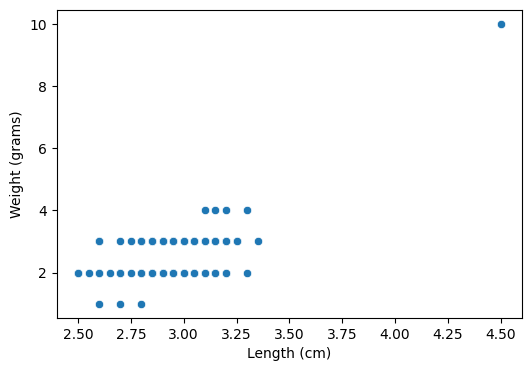

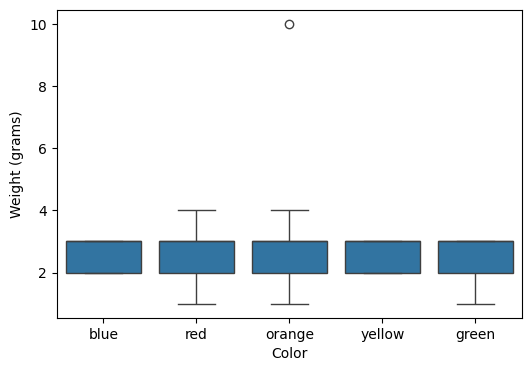

In [ ]:
# scatter plot for numerical features
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Length (cm)', y='Weight (grams)', data=df_individual)
plt.show()

# boxplot to explore weight distribution by color
plt.figure(figsize=(6, 4))
sns.boxplot(x='Color', y='Weight (grams)', data=df_individual)
plt.show()

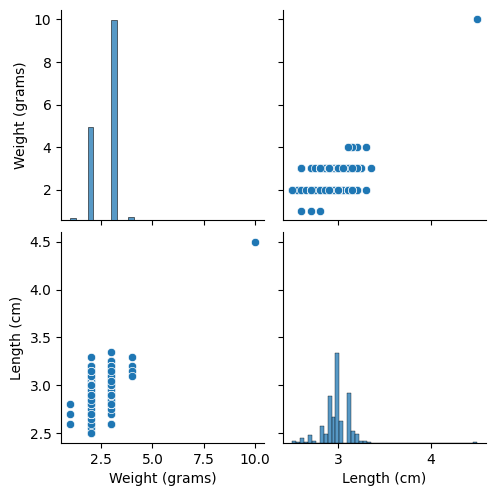

In [ ]:
# pairplot for numerical columns
sns.pairplot(df_individual[['Weight (grams)', 'Length (cm)']])
plt.show()

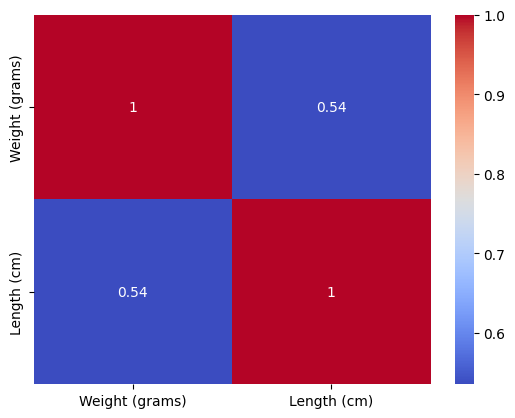

In [ ]:
# correlation heatmap (though in this case, we have only a couple of numerical variables)
sns.heatmap(df_individual[['Weight (grams)', 'Length (cm)']].corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
stat, p = stats.shapiro(df_individual['Weight (grams)'])
print(f"Shapiro-Wilk test for total Weight (grams): statistic={stat:.4f}, p-value={p:.4f}")
# a statistical test that checks for normality. If p > 0.05, the data is likely normal

stat, p = stats.shapiro(df_individual['Length (cm)'])
print(f"Shapiro-Wilk test for total Length (cm): statistic={stat:.4f}, p-value={p:.4f}")

for bag_num in range(1, 7):
    bag_data = df_individual[df_individual['Bag Number'] == bag_num]
    stat, p = stats.shapiro(bag_data['Weight (grams)'])
    print(f"Shapiro-Wilk test for Bag {bag_num} Weight (grams): statistic={stat:.4f}, p-value={p:.4f}")

    stat, p = stats.shapiro(bag_data['Length (cm)'])
    print(f"Shapiro-Wilk test for Bag {bag_num} Length (cm): statistic={stat:.4f}, p-value={p:.4f}")

Shapiro-Wilk test for total Weight (grams): statistic=0.5425, p-value=0.0000
Shapiro-Wilk test for total Length (cm): statistic=0.8061, p-value=0.0000
Shapiro-Wilk test for Bag 1 Weight (grams): statistic=0.7185, p-value=0.0000
Shapiro-Wilk test for Bag 1 Length (cm): statistic=0.9407, p-value=0.0063
Shapiro-Wilk test for Bag 2 Weight (grams): statistic=0.5150, p-value=0.0000
Shapiro-Wilk test for Bag 2 Length (cm): statistic=0.5557, p-value=0.0000
Shapiro-Wilk test for Bag 3 Weight (grams): statistic=0.6035, p-value=0.0000
Shapiro-Wilk test for Bag 3 Length (cm): statistic=0.8572, p-value=0.0000
Shapiro-Wilk test for Bag 4 Weight (grams): statistic=0.4305, p-value=0.0000
Shapiro-Wilk test for Bag 4 Length (cm): statistic=0.8525, p-value=0.0000
Shapiro-Wilk test for Bag 5 Weight (grams): statistic=0.6057, p-value=0.0000
Shapiro-Wilk test for Bag 5 Length (cm): statistic=0.9355, p-value=0.0038
Shapiro-Wilk test for Bag 6 Weight (grams): statistic=0.6187, p-value=0.0000
Shapiro-Wilk test

so none of these are normal (weight and length wise)

In [ ]:
# splitting data into different df for each team member to process
df_bag_1_and_2 = df_individual[df_individual['Bag Number'].isin([1, 2])] # team member 1
df_bag_3_and_4 = df_individual[df_individual['Bag Number'].isin([3, 4])] # team member 2
df_bag_5_and_6 = df_individual[df_individual['Bag Number'].isin([5, 6])] # team member 3

## Useful Functions

Function that reshapes the data into subgroups.

In [ ]:
def make_subgroups(data, subgroup_size):
  # reshape data into subgroups
  num_subgroups = len(data) // subgroup_size
  subgroups = data[:num_subgroups * subgroup_size].reshape(subgroup_size, num_subgroups)
  subgroups = subgroups.transpose()
  return subgroups

Function that takes the data, makes subgroups of the required subgroup size and creates the X bar and R charts.

In [ ]:
def plot_xbar_rchart_once(data, subgroup_size, A2, D3, D4, qc_label):
  """
  Plots X-bar and R charts with the QC label in the title and y-axis.
  Use if no points have special causes.
  No need to iteratively remove OOC points.

  Arguments:
      data: A NumPy array or Pandas Series of data.
      subgroup_size: The size of each subgroup.
      A2: A2 control chart constant.
      D3: D3 control chart constant.
      D4: D4 control chart constant.
      qc_label: The label for the quality control metric.
  """
  num_subgroups = len(data) // subgroup_size
  subgroups = data[:num_subgroups * subgroup_size].reshape(subgroup_size, num_subgroups)
  subgroups = subgroups.transpose()

  # calculate X-bar and R
  x_bar = np.mean(subgroups, axis=1)
  r = np.ptp(subgroups, axis=1)

  # calculate control limits
  x_bar_bar = np.mean(x_bar)
  R_bar = np.mean(r)
  UCL_xbar = x_bar_bar + (R_bar * A2)
  LCL_xbar = x_bar_bar - (R_bar * A2)
  UCL_R = R_bar * D4
  LCL_R = R_bar * D3

  # plotting X-bar R chart
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.plot(x_bar, marker='o')
  plt.axhline(x_bar_bar, color='r', linestyle='--', label='Overall Mean')
  plt.axhline(UCL_xbar, color='g', linestyle='--', label='UCL')
  plt.axhline(LCL_xbar, color='g', linestyle='--', label='LCL')
  plt.xticks(ticks=np.arange(0, num_subgroups), labels=np.arange(1, num_subgroups + 1))
  plt.title(f'X-bar Chart ({qc_label})')
  plt.xlabel('Subgroup')
  plt.ylabel(f'X-bar ({qc_label})')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(r, marker='o')
  plt.axhline(R_bar, color='r', linestyle='--', label='CL')
  plt.axhline(UCL_R, color='g', linestyle='--', label='UCL')
  plt.axhline(LCL_R, color='g', linestyle='--', label='LCL')
  plt.xticks(ticks=np.arange(0, num_subgroups), labels=np.arange(1, num_subgroups + 1))
  plt.title(f'R Chart ({qc_label})')
  plt.xlabel('Subgroup')
  plt.ylabel(f'R ({qc_label})')
  plt.legend()

  plt.tight_layout()
  plt.show()

  # check for R chart outliers
  r_outlier_indices = np.where((r > UCL_R) | ((r < LCL_R) & (LCL_R > 0)))[0]

  # store results of any out of control points
  out_of_control_points_r = []  # stores the actual out-of-control values
  out_of_control_indices_r = []  # stores the indices of these values in 'data'

  for idx in r_outlier_indices:
      subgroup = subgroups[idx]  # fet the subgroup that caused the OOC R value
      min_val, max_val = np.min(subgroup), np.max(subgroup)

      # store the actual values
      out_of_control_points_r.extend([min_val, max_val])

      # find their original indices in the 'data' array
      min_idx = np.where(data == min_val)[0][0]  # first occurrence of min_val
      max_idx = np.where(data == max_val)[0][0]  # first occurrence of max_val
      out_of_control_indices_r.extend([min_idx, max_idx])

  # convert to NumPy arrays
  out_of_control_points_r = np.array(out_of_control_points_r)
  out_of_control_indices_r = np.array(out_of_control_indices_r)


  out_of_control_xbar_points = []  # stores actual OOC values
  out_of_control_indices_xbar = []  # stores their indices in 'data'

  # only check X-bar if no R chart outliers
  # find indices of subgroups where X-bar is out of control
  x_bar_outlier_indices = np.where((x_bar > UCL_xbar) | (x_bar < LCL_xbar))[0]

  # extract actual data points and their indices
  for idx in x_bar_outlier_indices:
      subgroup = subgroups[idx]  # get the subgroup that caused the OOC X-bar
      out_of_control_xbar_points.extend(subgroup)  # store all values in the subgroup

      # find original indices in 'data'
      for point in subgroup:
          original_index = np.where(data == point)[0][0]  # First occurrence
          out_of_control_indices_xbar.append(original_index)

  # convert to NumPy arrays
  out_of_control_xbar_points = np.array(out_of_control_xbar_points)
  out_of_control_indices_xbar = np.array(out_of_control_indices_xbar)

  return out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_points_r, out_of_control_indices_r, x_bar_bar, R_bar, UCL_xbar, LCL_xbar, UCL_R, LCL_R

Function that takes the data and creates the IMR charts.

In [ ]:
def plot_IMR_chart(data, qc_label):
    """
    Plots Individuals-Moving Range (IMR) charts with the QC label in the title and y-axis.
    Use if no points have special causes.
    No need to iteratively remove OOC points.

    Arguments:
        data: A NumPy array or Pandas Series of individual data points.
        qc_label: The label for the quality control metric.
    """
    # calculate moving range
    mr = np.abs(np.diff(data))

    # control limits factors for R chart (D3 and D4)
    d2 = 1.128
    D4 = 3.267
    D3 = 0

    # calculate control limits for X-bar and MR charts
    x_bar = data  # for IMR, each individual point is the X-bar
    mr_bar = np.mean(mr)
    UCL_x = np.mean(x_bar) + (3 * mr_bar / d2)
    LCL_x = np.mean(x_bar) - (3 * mr_bar / d2)
    UCL_mr = D4 * mr_bar
    LCL_mr = D3 * mr_bar

    # plotting IMR chart
    plt.figure(figsize=(12, 6))

    # X-bar Chart
    plt.subplot(1, 2, 1)
    plt.plot(x_bar, marker='o')
    plt.axhline(np.mean(x_bar), color='r', linestyle='--', label='Overall Mean')
    plt.axhline(UCL_x, color='g', linestyle='--', label='UCL')
    plt.axhline(LCL_x, color='g', linestyle='--', label='LCL')
    plt.title(f'X-bar Chart ({qc_label})')
    plt.xlabel('Subgroup')
    plt.ylabel(f'X-bar ({qc_label})')
    plt.legend()

    # Moving Range (MR) Chart
    plt.subplot(1, 2, 2)
    plt.plot(mr, marker='o')
    plt.axhline(UCL_mr, color='r', linestyle='--', label='UCL')
    plt.axhline(mr_bar, color='g', linestyle='--', label='MR-bar')
    plt.axhline(LCL_mr, color='r', linestyle='--', label='LCL')
    plt.title(f'Moving Range (MR) Chart ({qc_label})')
    plt.xlabel('Sample')
    plt.ylabel(f'MR ({qc_label})')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # check for X-bar outliers
    x_bar_outlier_indices = np.where((x_bar > UCL_x) | (x_bar < LCL_x))[0]

    # lists to store results for X-bar outliers
    out_of_control_xbar_points = []  # stores the actual out-of-control values
    out_of_control_indices_xbar = []  # stores the indices of these values in 'data'

    for idx in x_bar_outlier_indices:
        out_of_control_xbar_points.append(data[idx])  # store the actual values
        out_of_control_indices_xbar.append(idx)  # store the indices of out-of-control points

    out_of_control_xbar_points = np.array(out_of_control_xbar_points)
    out_of_control_indices_xbar = np.array(out_of_control_indices_xbar)

    # check for MR outliers
    mr_outlier_indices = np.where((mr > UCL_mr) | (mr < LCL_mr))[0]

    # lists to store results for MR outliers
    out_of_control_mr_points = []  # stores the actual out-of-control values
    out_of_control_indices_mr = []  # stores the indices of these values in 'data'

    for idx in mr_outlier_indices:
        out_of_control_mr_points.append(mr[idx])
        out_of_control_indices_mr.append(idx + 1)  # adjusted by 1 since MR is the difference between two points

    out_of_control_mr_points = np.array(out_of_control_mr_points)
    out_of_control_indices_mr = np.array(out_of_control_indices_mr)

    # return the results
    return out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr


Function that handles the out of control points by printing them out then removing them.

In [ ]:
def handle_out_of_control_points(df_individual, out_of_control_points, out_of_control_indices, numpy_data):
    """
    Prints out the out-of-control points and their special causes and removes points with special causes.

    Arguments:
        df_individual: DataFrame containing information about points and their causes.
        out_of_control_points: List or array of the out-of-control points.
        out_of_control_indices: List or array of the indices corresponding to the out-of-control points.
        numpy_data: NumPy array containing the original data to modify.

    Returns:
        numpy_data: Modified NumPy array with points having special causes removed.
        common_causes_index: List of indices with common causes.
        special_causes_index: List of indices with special causes.
    """
    common_causes_index = []  # indices with common causes
    special_causes_index = []  # indices with special causes

    # iterate over out-of-control points and their corresponding indices
    for ooc_point, idx in zip(out_of_control_points, out_of_control_indices):
        matching_row = df_individual.iloc[idx]  # get row by index

        if not matching_row.empty:
            print(f"Point at index {idx} with value {ooc_point} has special causes: {matching_row['Notes']}")
            if matching_row['Deformity'] == False:
                common_causes_index.append(idx)
            else:
                special_causes_index.append(idx)
        else:
            print(f"Point at index {idx} with value {ooc_point} does not have special causes.")

    # remove points with special causes from the NumPy data
    numpy_data = np.delete(numpy_data, special_causes_index)

    return numpy_data, common_causes_index, special_causes_index

Function that takes the data and creates the p charts for color proportions.

In [ ]:
def plot_p_chart_color_proportions(df):
    """
    Plots p-charts for color proportions of Sour Patch Kids in each bag.

    Arguments:
        df: A DataFrame with columns 'Bag Number' and 'Color'.
    """
    # calculate total candies per bag
    total_per_bag = df.groupby('Bag Number').size()

    # calculate color proportions per bag
    color_counts = df.groupby(['Bag Number', 'Color']).size().unstack(fill_value=0)
    color_proportions = color_counts.div(total_per_bag, axis=0)

    # compute overall mean proportion for each color
    p_bar = color_proportions.mean()

    # compute control limits
    n = total_per_bag.mean()  # approximate average sample size
    UCL = p_bar + 3 * np.sqrt((p_bar * (1 - p_bar)) / n)
    LCL = p_bar - 3 * np.sqrt((p_bar * (1 - p_bar)) / n)
    LCL[LCL < 0] = 0  # control limits cannot be negative

    # plot the p-chart
    fig, axes = plt.subplots(len(color_proportions.columns), 1, figsize=(10, 2.5 * len(color_proportions.columns)), sharex=True)

    if len(color_proportions.columns) == 1:
        axes = [axes]  # ensure axes is always iterable

    for i, color in enumerate(color_proportions.columns):
        axes[i].plot(color_proportions.index, color_proportions[color], marker='o', linestyle='-', label=f'Proportion of {color}')
        axes[i].axhline(p_bar[color], color='green', linestyle='--', label='Mean')
        axes[i].axhline(UCL[color], color='red', linestyle='--', label='UCL')
        axes[i].axhline(LCL[color], color='red', linestyle='--', label='LCL')

        axes[i].set_ylabel(f'{color} Proportion')
        axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Bag Number')
    plt.suptitle('p-Chart for Sour Patch Kids Color Proportion')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

#4.0 Charts and detecting out of control points for bag numbers 1 and 2



In [ ]:
# data
df_bag_1_and_2
df_bag_1 = df_bag_1_and_2[df_bag_1_and_2['Bag Number'] == 1]
df_bag_2 = df_bag_1_and_2[df_bag_1_and_2['Bag Number'] == 2]

numpy_bag1_weight = df_bag_1['Weight (grams)'].values
numpy_bag1_length = df_bag_1['Length (cm)'].values

numpy_bag2_weight = df_bag_2['Weight (grams)'].values
numpy_bag2_length = df_bag_2['Length (cm)'].values

numpy_bag1bag2_weight = np.concatenate((numpy_bag1_weight, numpy_bag2_weight))
numpy_bag1bag2_length = np.concatenate((numpy_bag1_length, numpy_bag2_length))

## X bar R chart

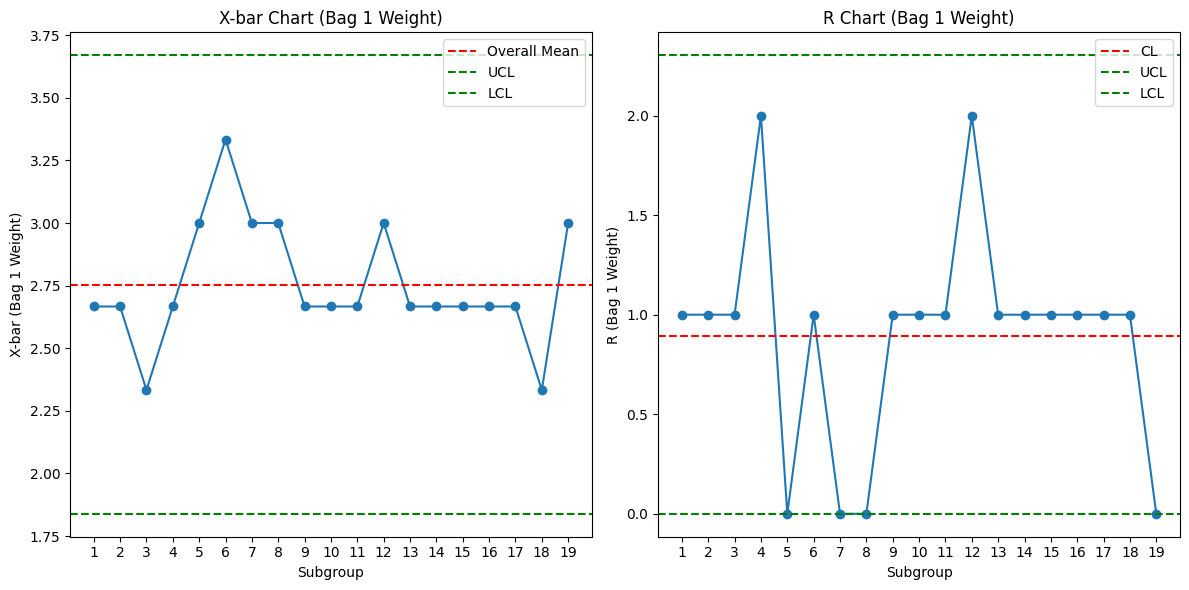

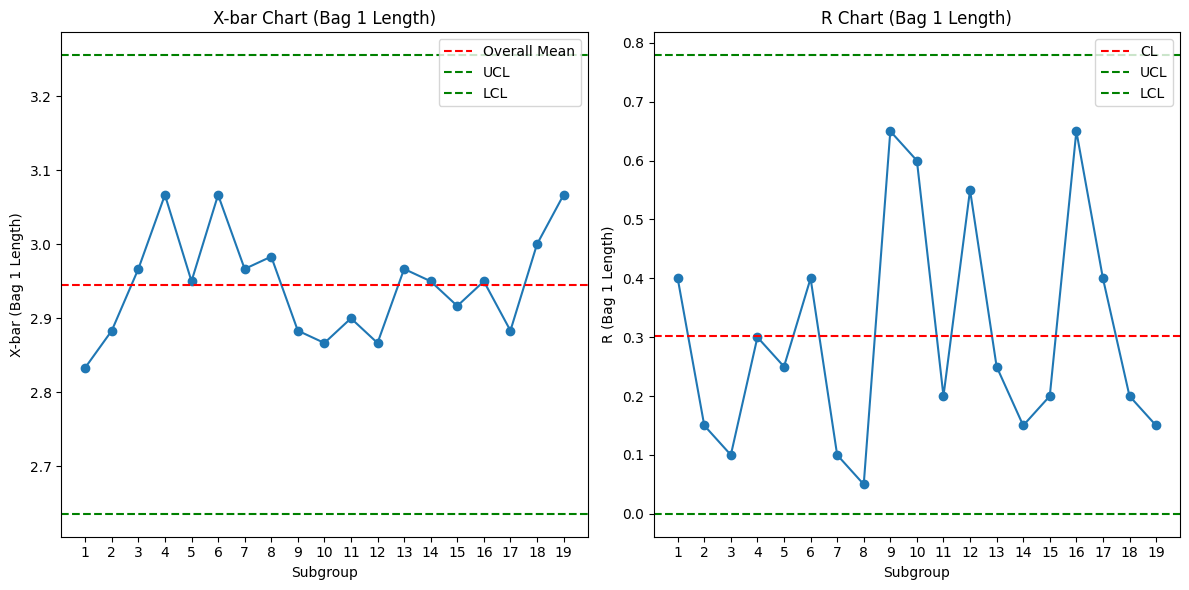

(array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 np.float64(2.9456140350877194),
 np.float64(0.3026315789473684),
 np.float64(3.2552061403508774),
 np.float64(2.6360219298245613),
 np.float64(0.7789736842105263),
 np.float64(0.0))

In [ ]:
# control limits factors for X-bar chart (A2)
A2 = 1.023
# control limits factors for R chart (D3 and D4)
D3 = 0
D4 = 2.574

############## FOR JUST BAG 1 ##############
plot_xbar_rchart_once(numpy_bag1_weight, 3, A2, D3, D4, "Bag 1 Weight")

plot_xbar_rchart_once(numpy_bag1_length, 3, A2, D3, D4, "Bag 1 Length")

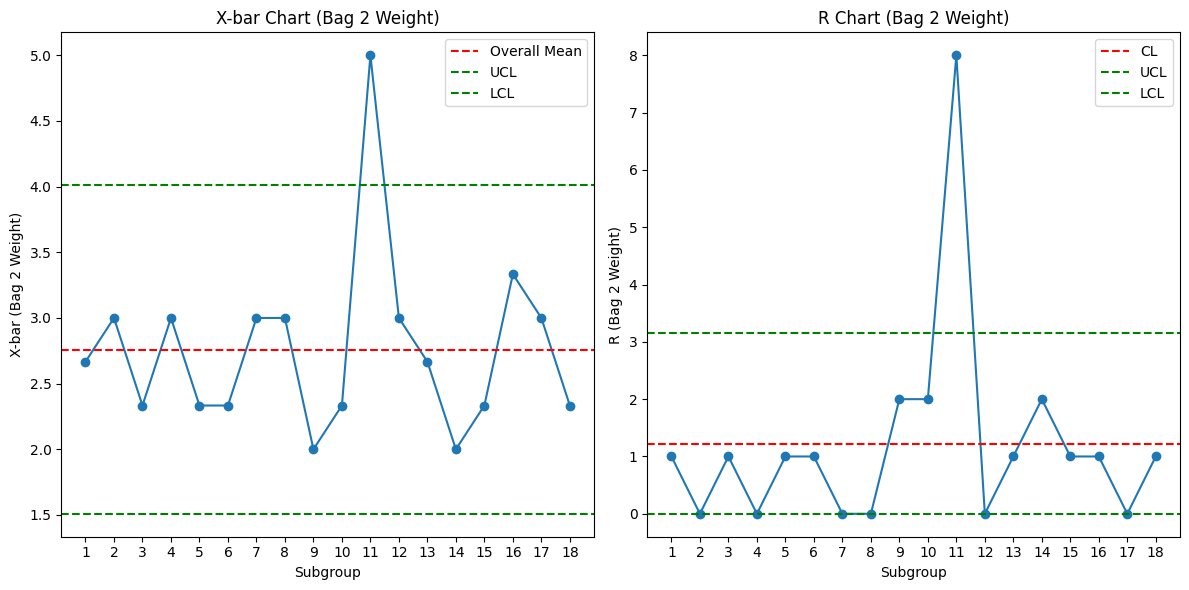

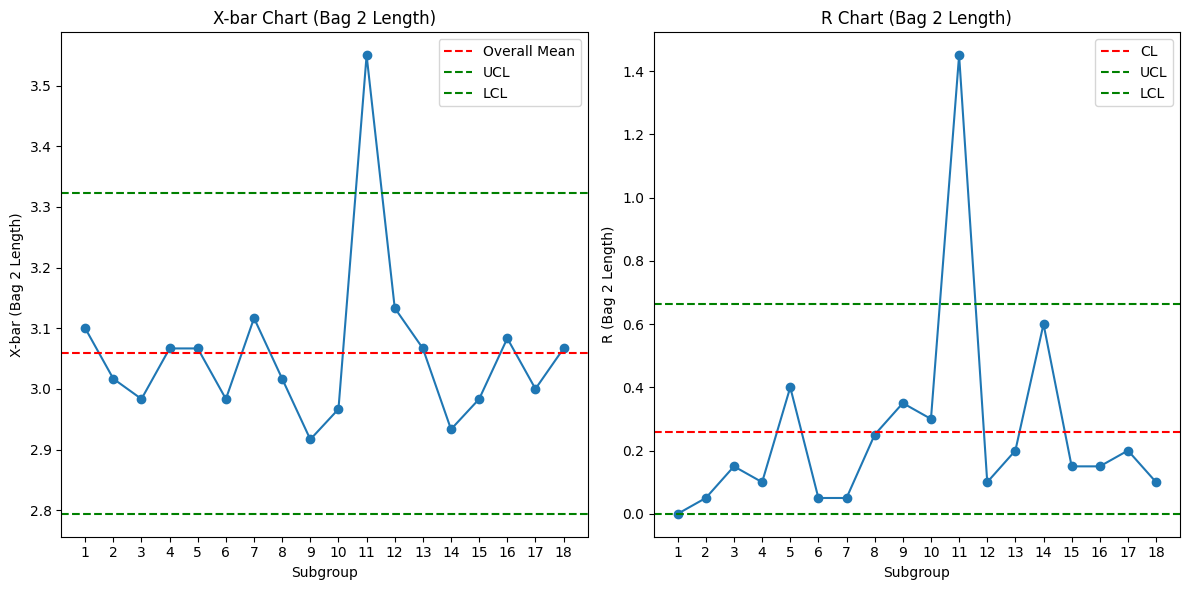

(array([3.1 , 4.5 , 3.05]),
 array([ 0, 28, 37]),
 array([3.05, 4.5 ]),
 array([37, 28]),
 np.float64(3.058333333333333),
 np.float64(0.25833333333333336),
 np.float64(3.322608333333333),
 np.float64(2.794058333333333),
 np.float64(0.66495),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 2 ##############
plot_xbar_rchart_once(numpy_bag2_weight, 3, A2, D3, D4, "Bag 2 Weight")

plot_xbar_rchart_once(numpy_bag2_length, 3, A2, D3, D4, "Bag 2 Length")


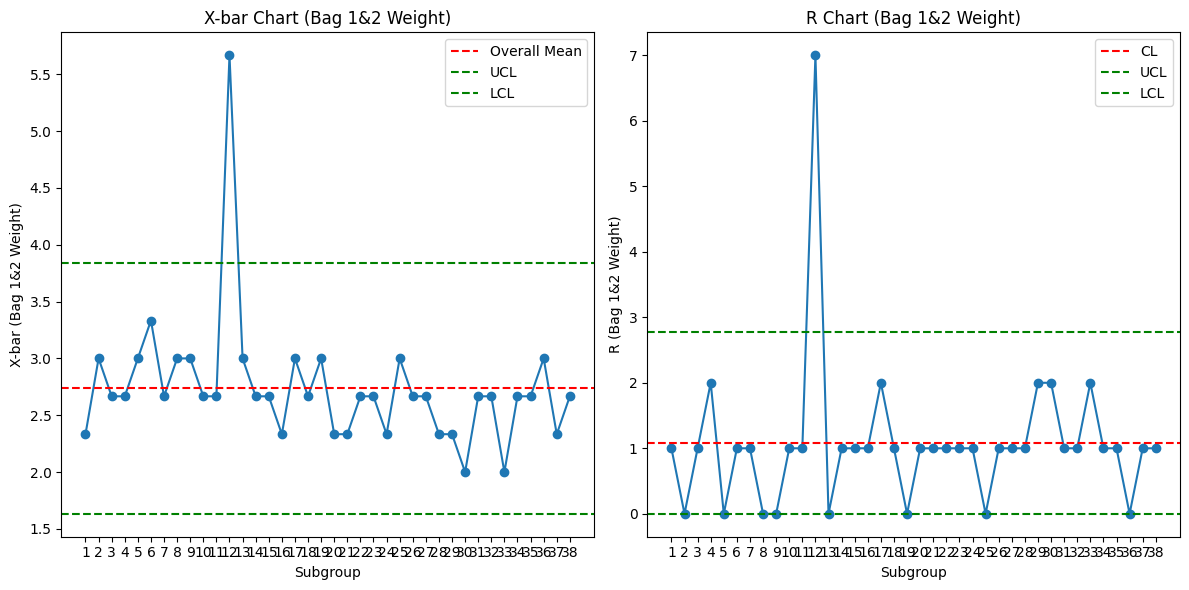

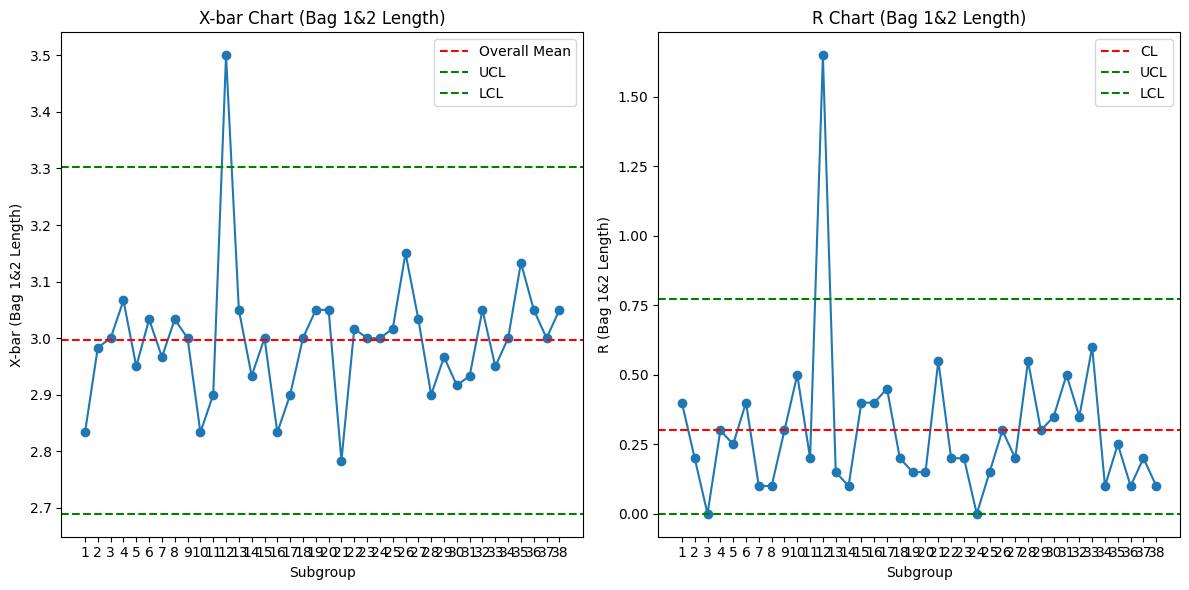

In [ ]:
length_data = plot_xbar_rchart_once(numpy_bag1bag2_weight, 3, A2, D3, D4, "Bag 1&2 Weight")

length_data_r = plot_xbar_rchart_once(numpy_bag1bag2_length, 3, A2, D3, D4, "Bag 1&2 Length")

## IMR

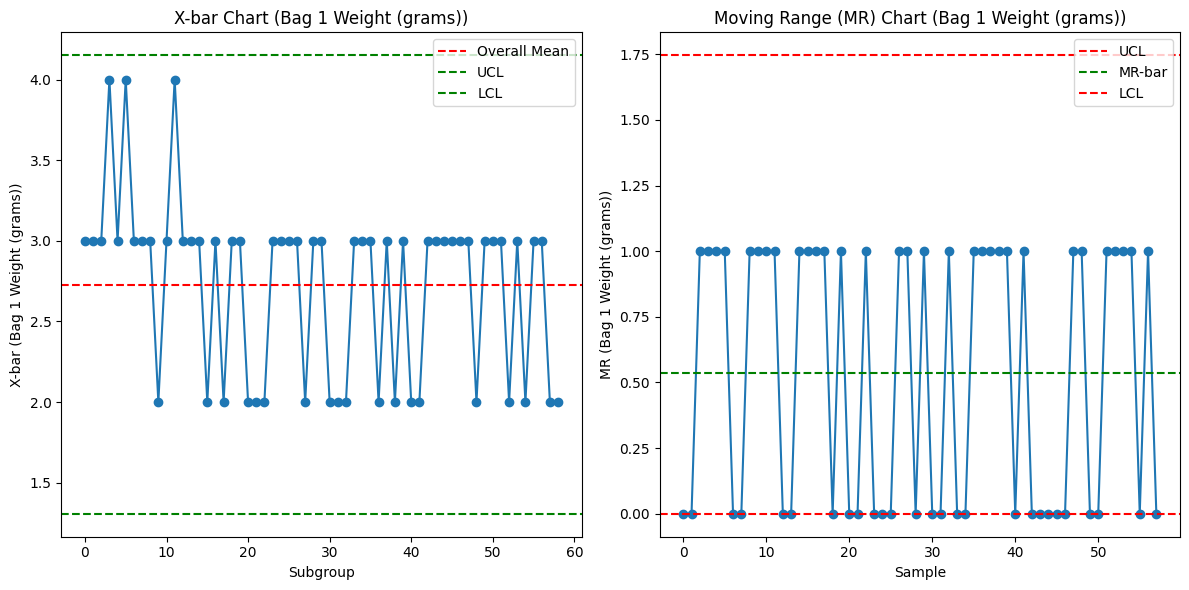

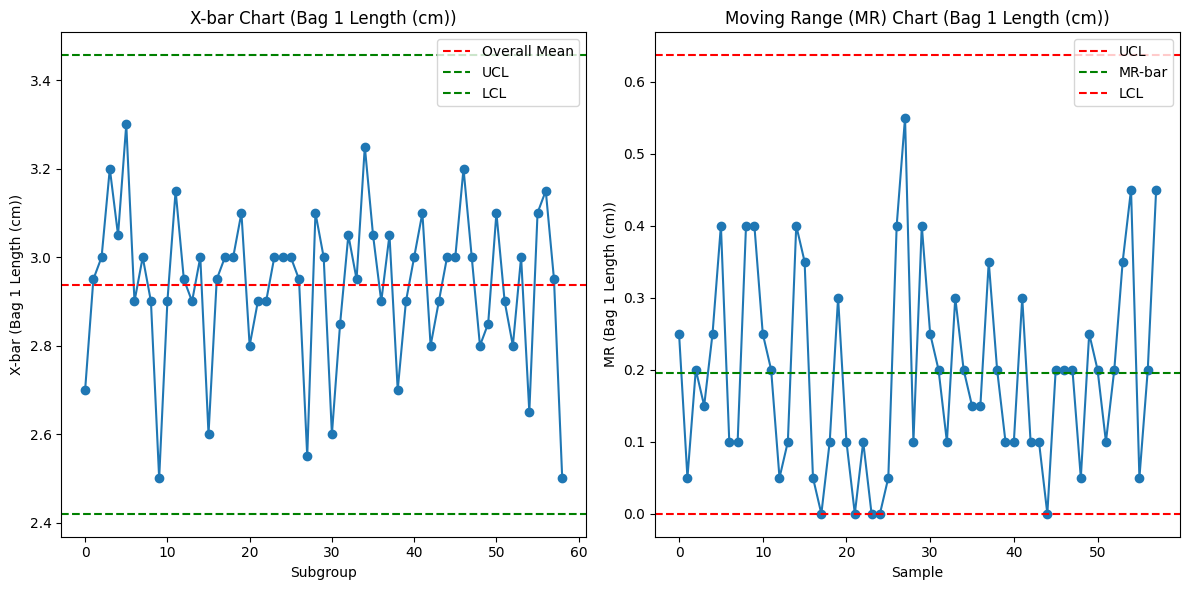

(array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([2.7 , 2.95, 3.  , 3.2 , 3.05, 3.3 , 2.9 , 3.  , 2.9 , 2.5 , 2.9 ,
        3.15, 2.95, 2.9 , 3.  , 2.6 , 2.95, 3.  , 3.  , 3.1 , 2.8 , 2.9 ,
        2.9 , 3.  , 3.  , 3.  , 2.95, 2.55, 3.1 , 3.  , 2.6 , 2.85, 3.05,
        2.95, 3.25, 3.05, 2.9 , 3.05, 2.7 , 2.9 , 3.  , 3.1 , 2.8 , 2.9 ,
        3.  , 3.  , 3.2 , 3.  , 2.8 , 2.85, 3.1 , 2.9 , 2.8 , 3.  , 2.65,
        3.1 , 3.15, 2.95, 2.5 ]),
 np.float64(0.19482758620689655),
 np.float64(3.456294067174851),
 np.float64(2.419977119265827),
 np.float64(0.636501724137931),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 1 ##############
plot_IMR_chart(numpy_bag1_weight, 'Bag 1 Weight (grams)')

plot_IMR_chart(numpy_bag1_length, 'Bag 1 Length (cm)')

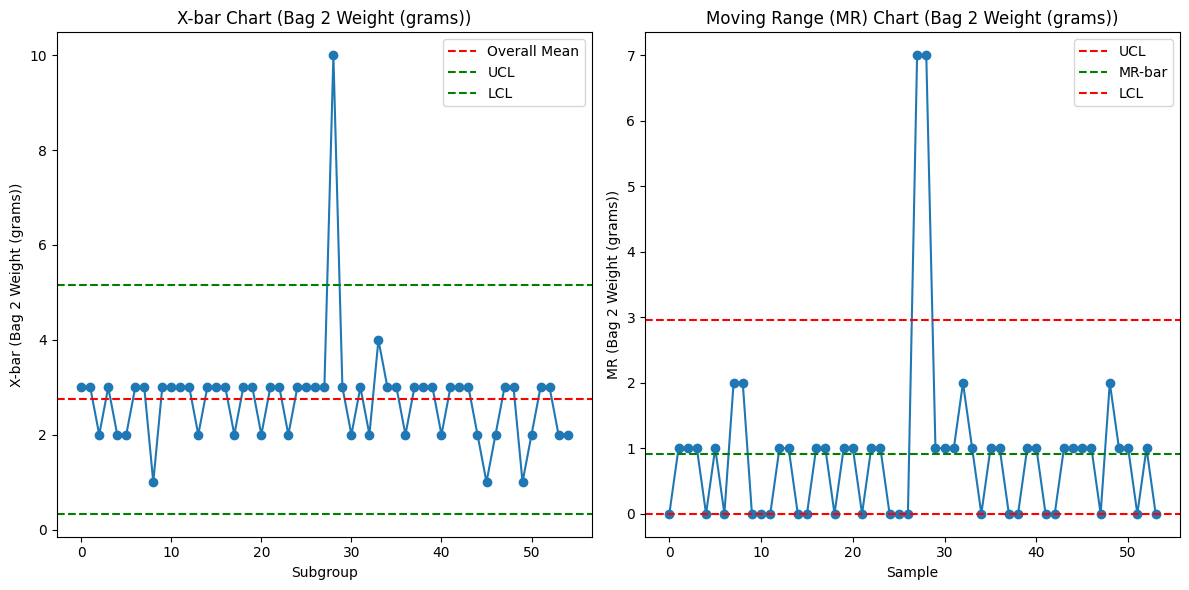

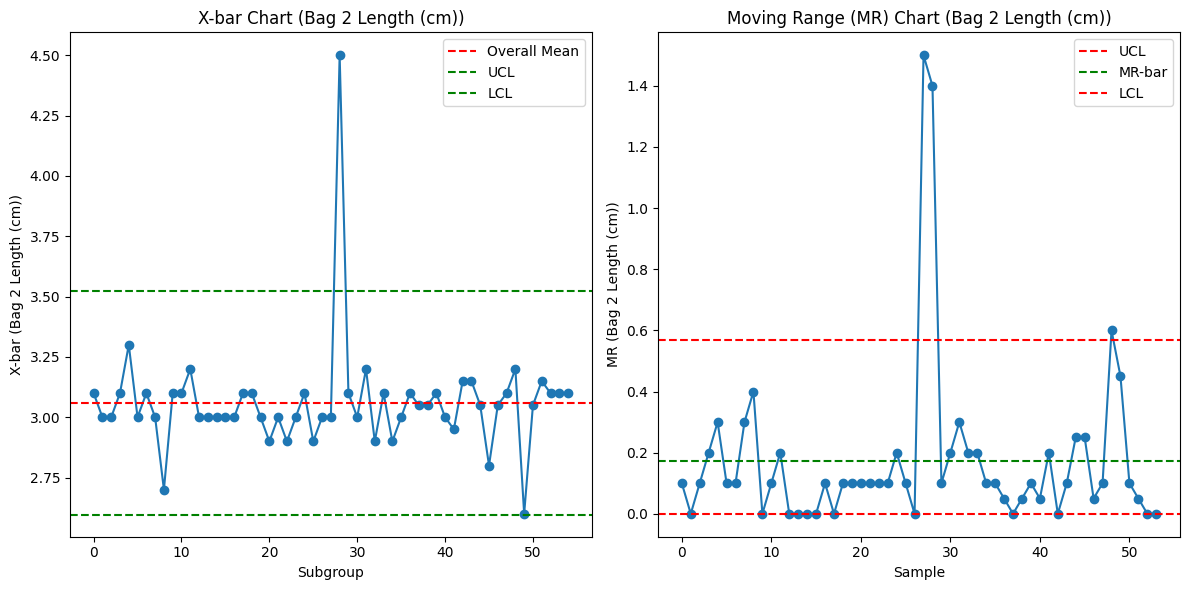

(array([4.5]),
 array([28]),
 array([1.5, 1.4, 0.6]),
 array([28, 29, 49]),
 array([3.1 , 3.  , 3.  , 3.1 , 3.3 , 3.  , 3.1 , 3.  , 2.7 , 3.1 , 3.1 ,
        3.2 , 3.  , 3.  , 3.  , 3.  , 3.  , 3.1 , 3.1 , 3.  , 2.9 , 3.  ,
        2.9 , 3.  , 3.1 , 2.9 , 3.  , 3.  , 4.5 , 3.1 , 3.  , 3.2 , 2.9 ,
        3.1 , 2.9 , 3.  , 3.1 , 3.05, 3.05, 3.1 , 3.  , 2.95, 3.15, 3.15,
        3.05, 2.8 , 3.05, 3.1 , 3.2 , 2.6 , 3.05, 3.15, 3.1 , 3.1 , 3.1 ]),
 np.float64(0.1740740740740741),
 np.float64(3.522053872053872),
 np.float64(2.5961279461279454),
 np.float64(0.5687000000000001),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 2 ##############
plot_IMR_chart(numpy_bag2_weight, 'Bag 2 Weight (grams)')

plot_IMR_chart(numpy_bag2_length, 'Bag 2 Length (cm)')

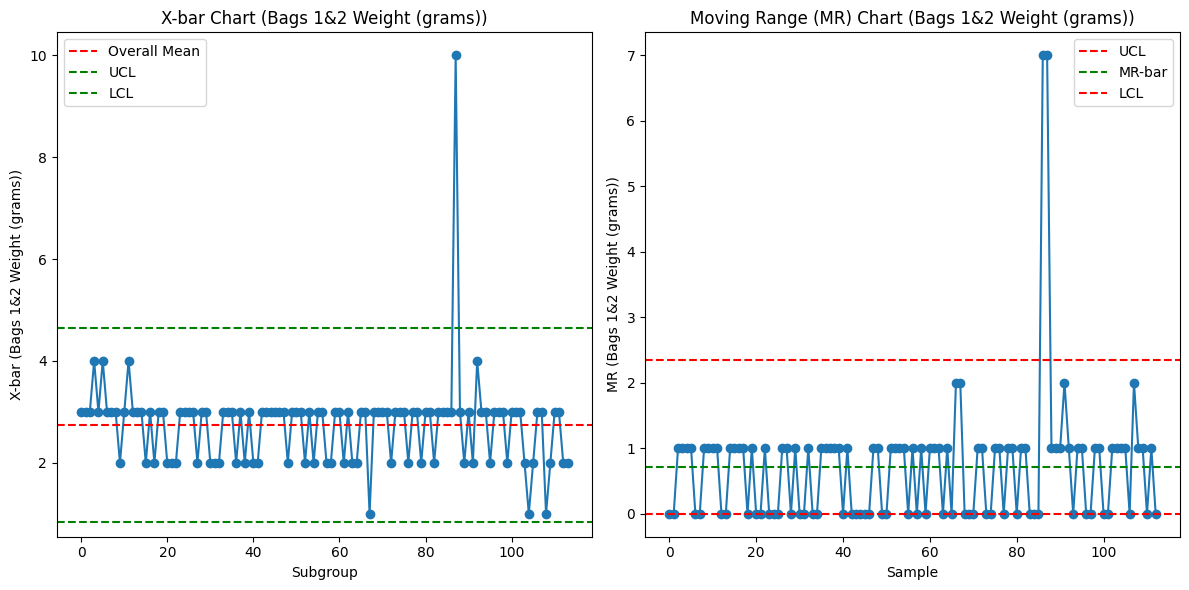

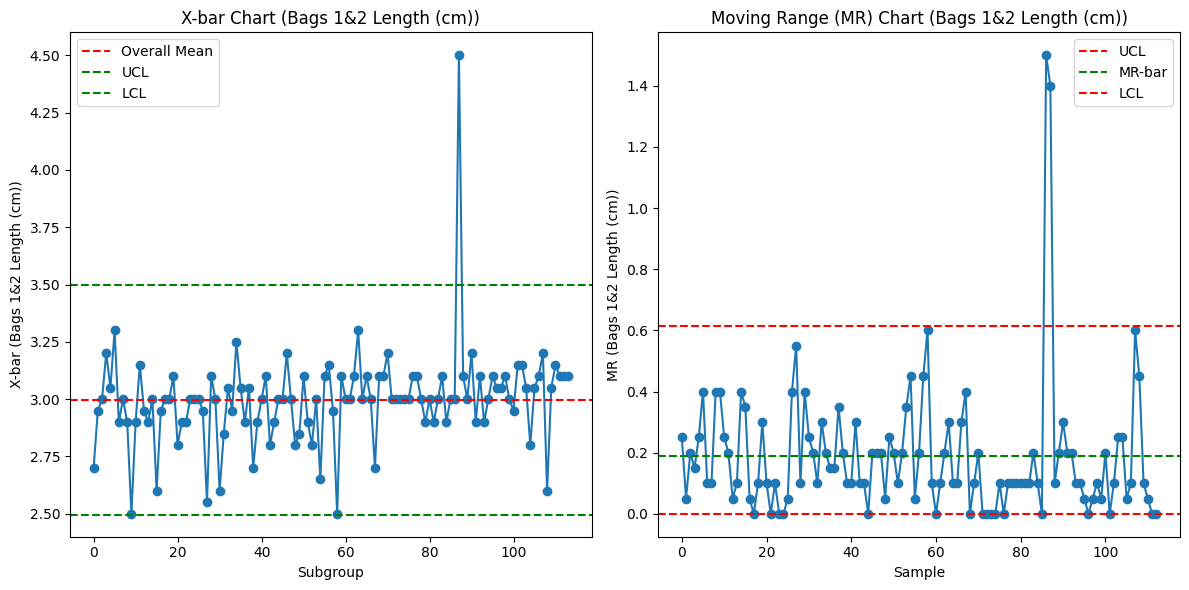

(array([4.5]),
 array([87]),
 array([1.5, 1.4]),
 array([87, 88]),
 array([2.7 , 2.95, 3.  , 3.2 , 3.05, 3.3 , 2.9 , 3.  , 2.9 , 2.5 , 2.9 ,
        3.15, 2.95, 2.9 , 3.  , 2.6 , 2.95, 3.  , 3.  , 3.1 , 2.8 , 2.9 ,
        2.9 , 3.  , 3.  , 3.  , 2.95, 2.55, 3.1 , 3.  , 2.6 , 2.85, 3.05,
        2.95, 3.25, 3.05, 2.9 , 3.05, 2.7 , 2.9 , 3.  , 3.1 , 2.8 , 2.9 ,
        3.  , 3.  , 3.2 , 3.  , 2.8 , 2.85, 3.1 , 2.9 , 2.8 , 3.  , 2.65,
        3.1 , 3.15, 2.95, 2.5 , 3.1 , 3.  , 3.  , 3.1 , 3.3 , 3.  , 3.1 ,
        3.  , 2.7 , 3.1 , 3.1 , 3.2 , 3.  , 3.  , 3.  , 3.  , 3.  , 3.1 ,
        3.1 , 3.  , 2.9 , 3.  , 2.9 , 3.  , 3.1 , 2.9 , 3.  , 3.  , 4.5 ,
        3.1 , 3.  , 3.2 , 2.9 , 3.1 , 2.9 , 3.  , 3.1 , 3.05, 3.05, 3.1 ,
        3.  , 2.95, 3.15, 3.15, 3.05, 2.8 , 3.05, 3.1 , 3.2 , 2.6 , 3.05,
        3.15, 3.1 , 3.1 , 3.1 ]),
 np.float64(0.18849557522123897),
 np.float64(3.4978092472755984),
 np.float64(2.4951732088647525),
 np.float64(0.6158150442477877),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAGS 1 and 2 ##############
plot_IMR_chart(numpy_bag1bag2_weight, 'Bags 1&2 Weight (grams)')

plot_IMR_chart(numpy_bag1bag2_length, 'Bags 1&2 Length (cm)')

## P chart

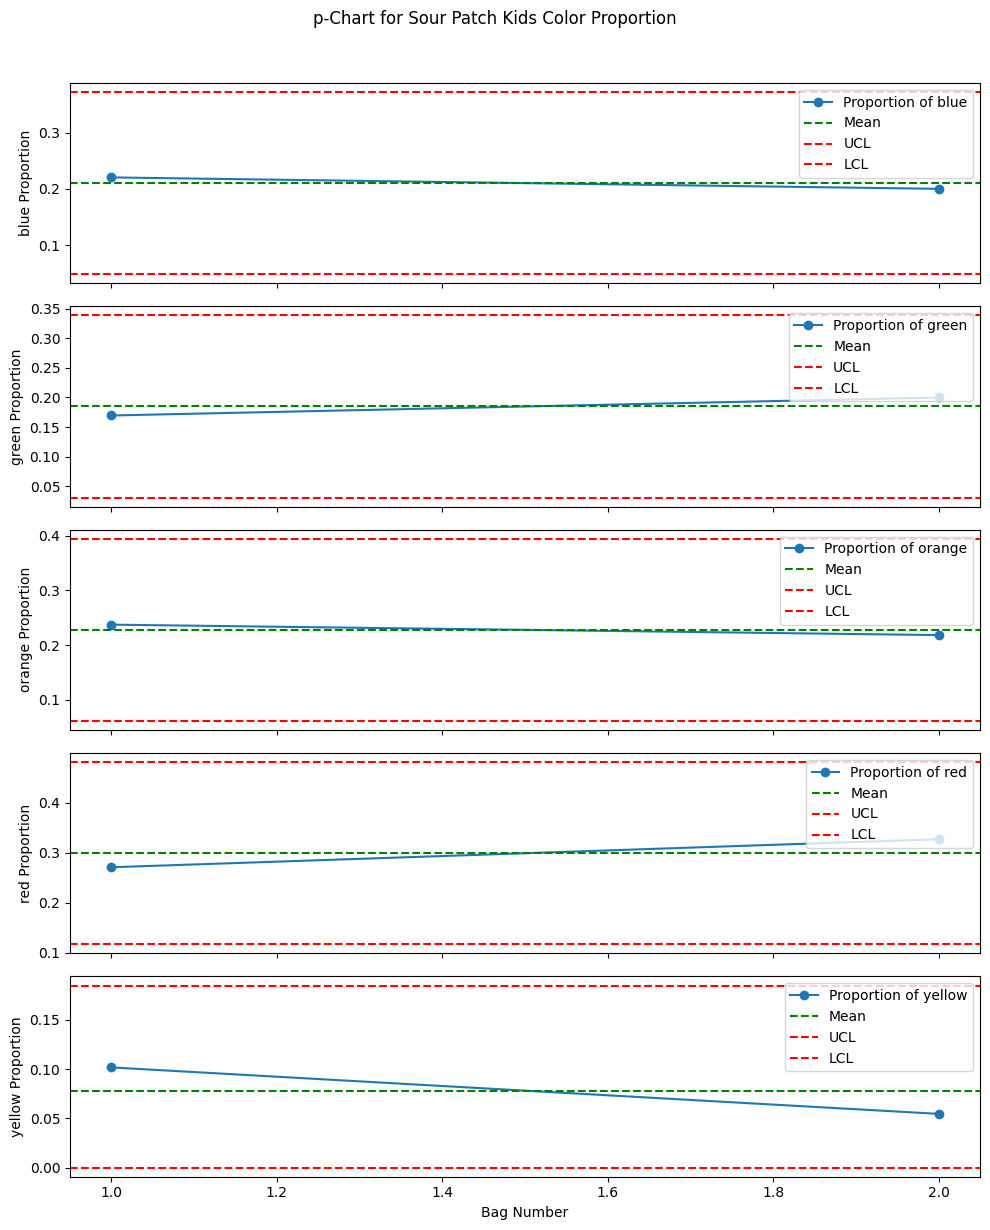

In [ ]:
plot_p_chart_color_proportions(df_bag_1_and_2)

#5.0  Charts and detecting out of control points for bag numbers 3 and 4

In [ ]:
# data
df_bag_3_and_4

df_bag_3 = df_bag_3_and_4[df_bag_3_and_4['Bag Number'] == 3]
df_bag_4 = df_bag_3_and_4[df_bag_3_and_4['Bag Number'] == 4]

numpy_bag3_weight = df_bag_3['Weight (grams)'].values
numpy_bag3_length = df_bag_3['Length (cm)'].values

numpy_bag4_weight = df_bag_4['Weight (grams)'].values
numpy_bag4_length = df_bag_4['Length (cm)'].values

numpy_bag3bag4_weight = np.concatenate((numpy_bag3_weight, numpy_bag4_weight))
numpy_bag3bag4_length = np.concatenate((numpy_bag3_length, numpy_bag4_length))

## X bar R chart

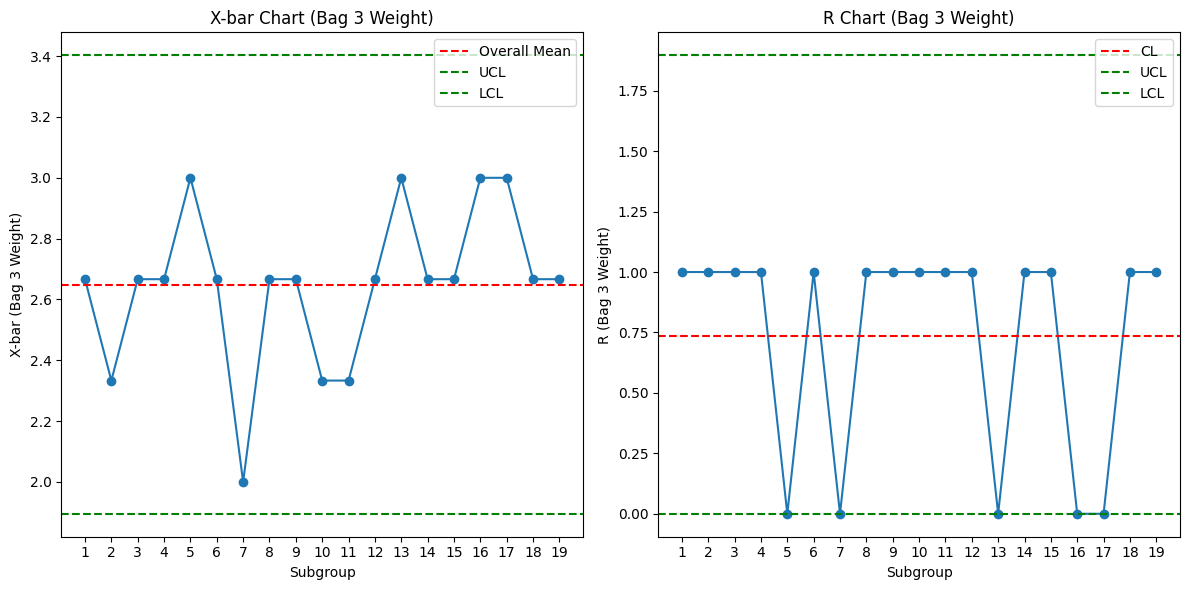

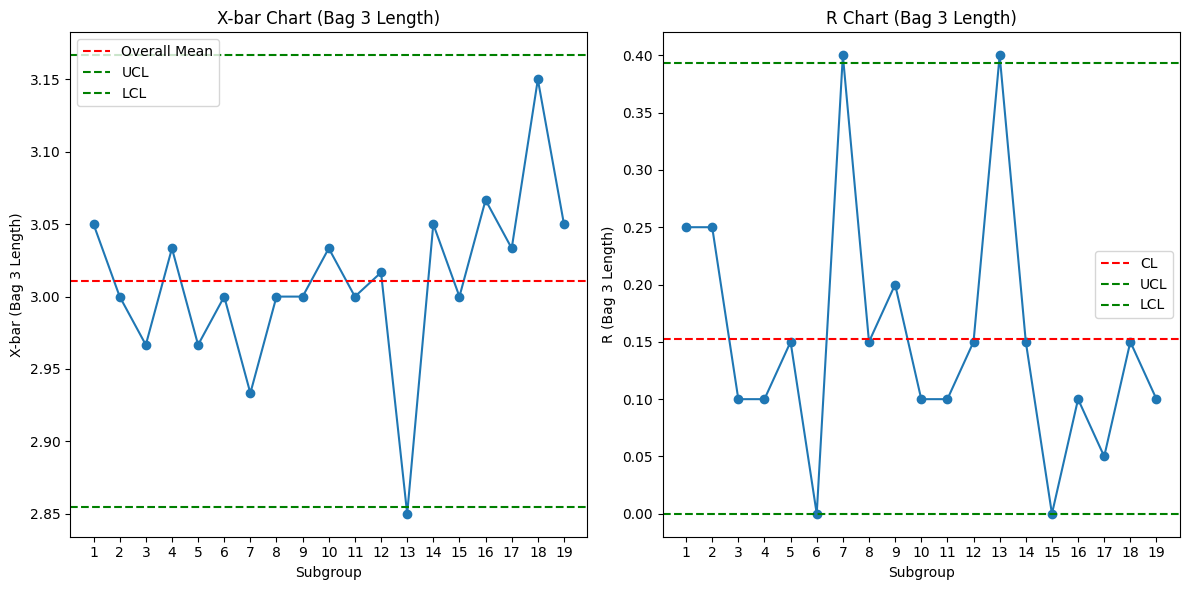

(array([3.  , 2.95, 2.6 ]),
 array([ 0,  1, 50]),
 array([2.7, 3.1, 2.6, 3. ]),
 array([ 6, 15, 50,  0]),
 np.float64(3.0105263157894733),
 np.float64(0.1526315789473684),
 np.float64(3.166668421052631),
 np.float64(2.8543842105263155),
 np.float64(0.3928736842105262),
 np.float64(0.0))

In [ ]:
# control limits factors for X-bar chart (A2)
A2 = 1.023
# control limits factors for R chart (D3 and D4)
D3 = 0
D4 = 2.574

############## FOR JUST BAG 3 ##############
plot_xbar_rchart_once(numpy_bag3_weight, 3, A2, D3, D4, "Bag 3 Weight")
# no special causes -- keep OOC points

plot_xbar_rchart_once(numpy_bag3_length, 3, A2, D3, D4, "Bag 3 Length")

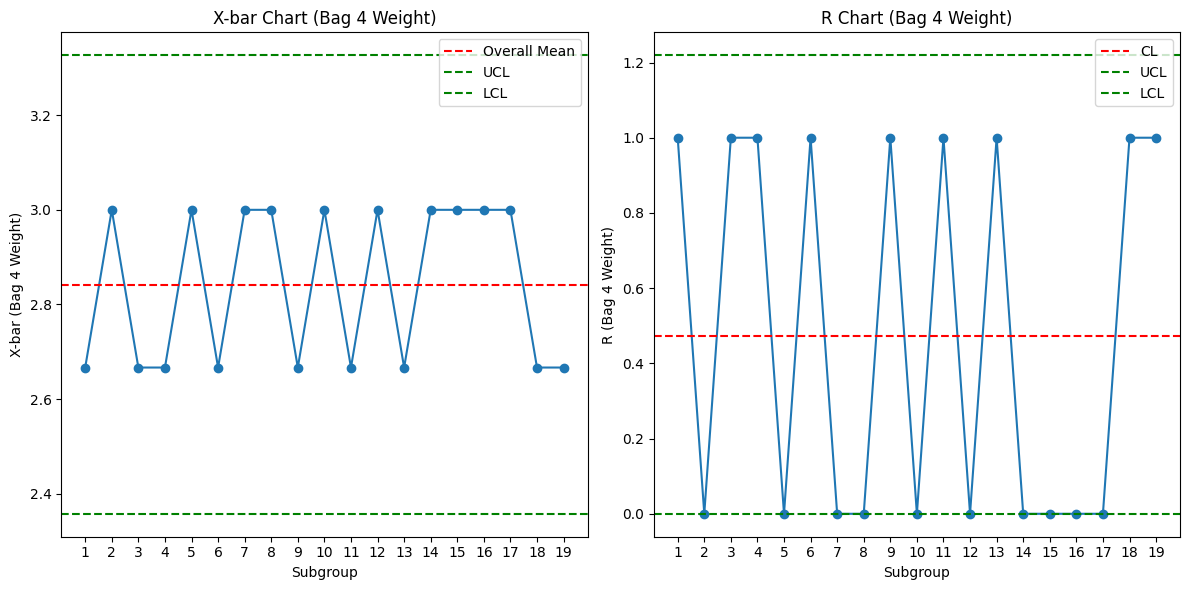

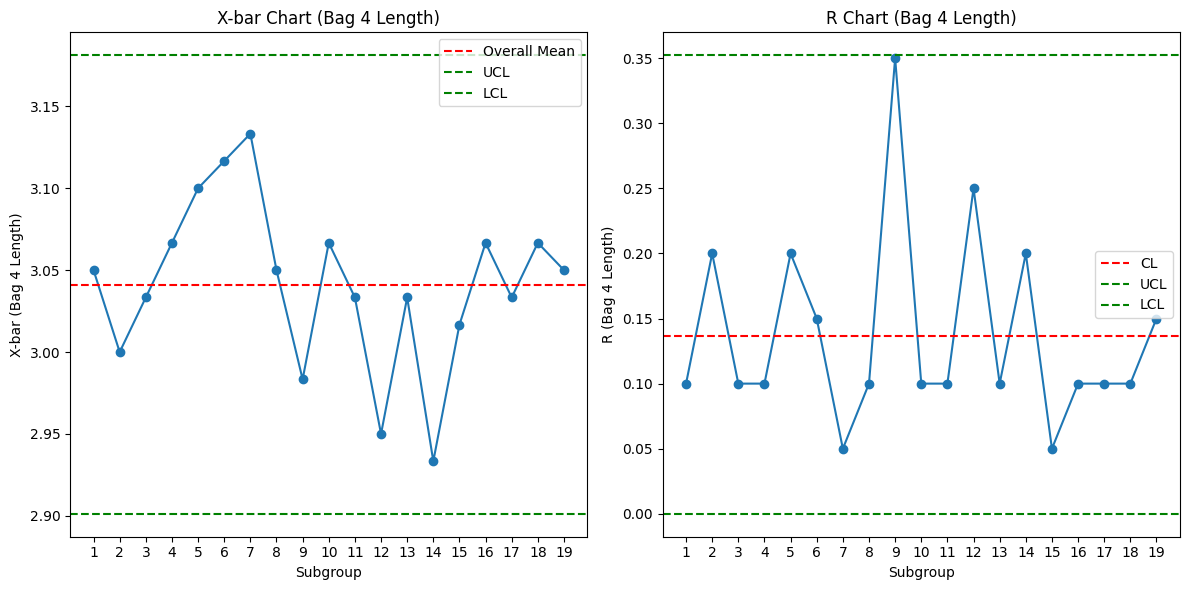

(array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 np.float64(3.0412280701754386),
 np.float64(0.13684210526315796),
 np.float64(3.181217543859649),
 np.float64(2.901238596491228),
 np.float64(0.35223157894736856),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 4 ##############
plot_xbar_rchart_once(numpy_bag4_weight, 3, A2, D3, D4, "Bag 4 Weight")
# no special causes -- keep OOC points

plot_xbar_rchart_once(numpy_bag4_length, 3, A2, D3, D4, "Bag 4 Length")
# no special causes -- keep OOC points


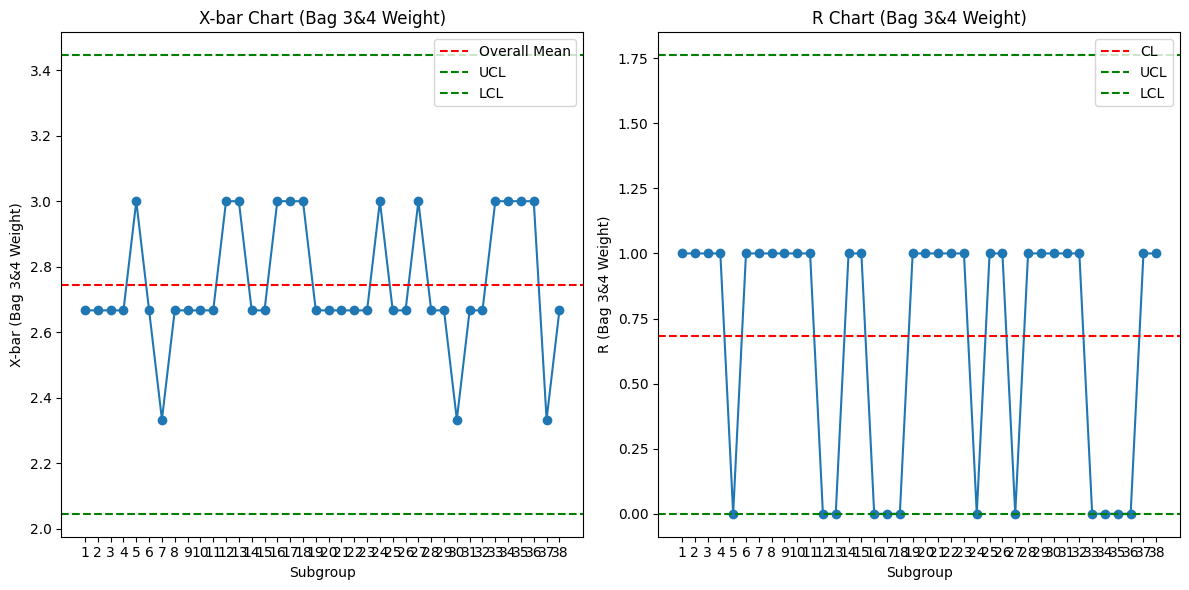

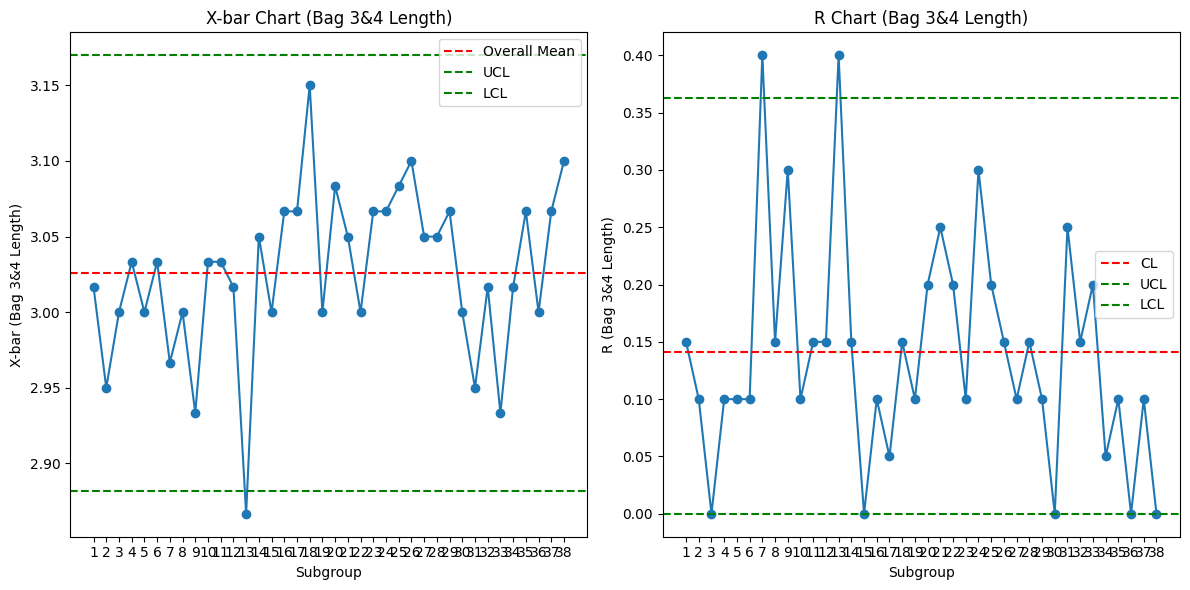

(array([3. , 2.6, 3. ]),
 array([ 0, 50,  0]),
 array([2.7, 3.1, 2.6, 3. ]),
 array([ 6, 15, 50,  0]),
 np.float64(3.025877192982456),
 np.float64(0.14078947368421052),
 np.float64(3.1699048245614034),
 np.float64(2.881849561403509),
 np.float64(0.36239210526315785),
 np.float64(0.0))

In [ ]:
############## FOR BOTH BAGS 3 AND 4 ##############
plot_info = plot_xbar_rchart_once(numpy_bag3bag4_weight, 3, A2, D3, D4, "Bag 3&4 Weight")

plot_xbar_rchart_once(numpy_bag3bag4_length, 3, A2, D3, D4, "Bag 3&4 Length")

## IMR

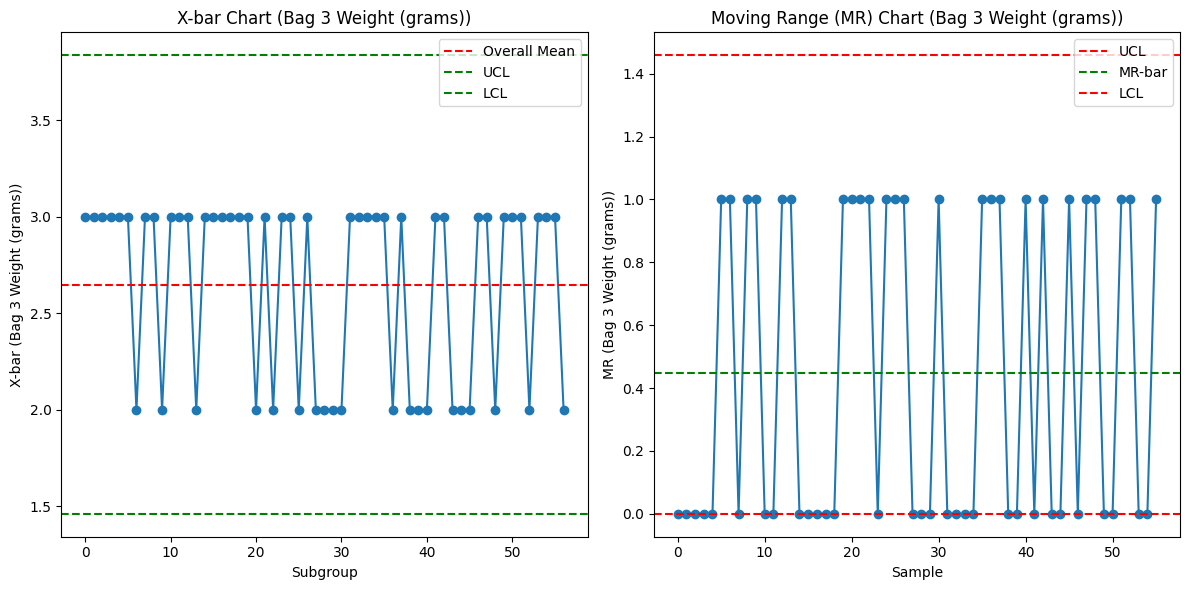

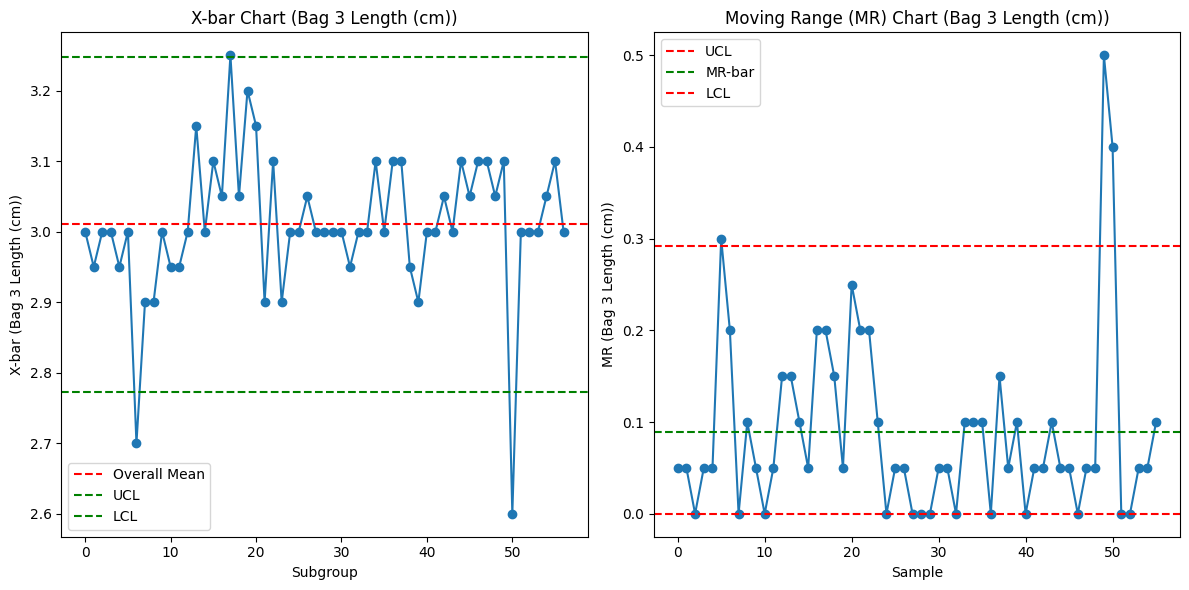

(array([2.7 , 3.25, 2.6 ]),
 array([ 6, 17, 50]),
 array([0.3, 0.5, 0.4]),
 array([ 6, 50, 51]),
 array([3.  , 2.95, 3.  , 3.  , 2.95, 3.  , 2.7 , 2.9 , 2.9 , 3.  , 2.95,
        2.95, 3.  , 3.15, 3.  , 3.1 , 3.05, 3.25, 3.05, 3.2 , 3.15, 2.9 ,
        3.1 , 2.9 , 3.  , 3.  , 3.05, 3.  , 3.  , 3.  , 3.  , 2.95, 3.  ,
        3.  , 3.1 , 3.  , 3.1 , 3.1 , 2.95, 2.9 , 3.  , 3.  , 3.05, 3.  ,
        3.1 , 3.05, 3.1 , 3.1 , 3.05, 3.1 , 2.6 , 3.  , 3.  , 3.  , 3.05,
        3.1 , 3.  ]),
 np.float64(0.0892857142857143),
 np.float64(3.2479883218685015),
 np.float64(2.773064309710447),
 np.float64(0.29169642857142863),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 3 ##############
plot_IMR_chart(numpy_bag3_weight, 'Bag 3 Weight (grams)')

plot_IMR_chart(numpy_bag3_length, 'Bag 3 Length (cm)')

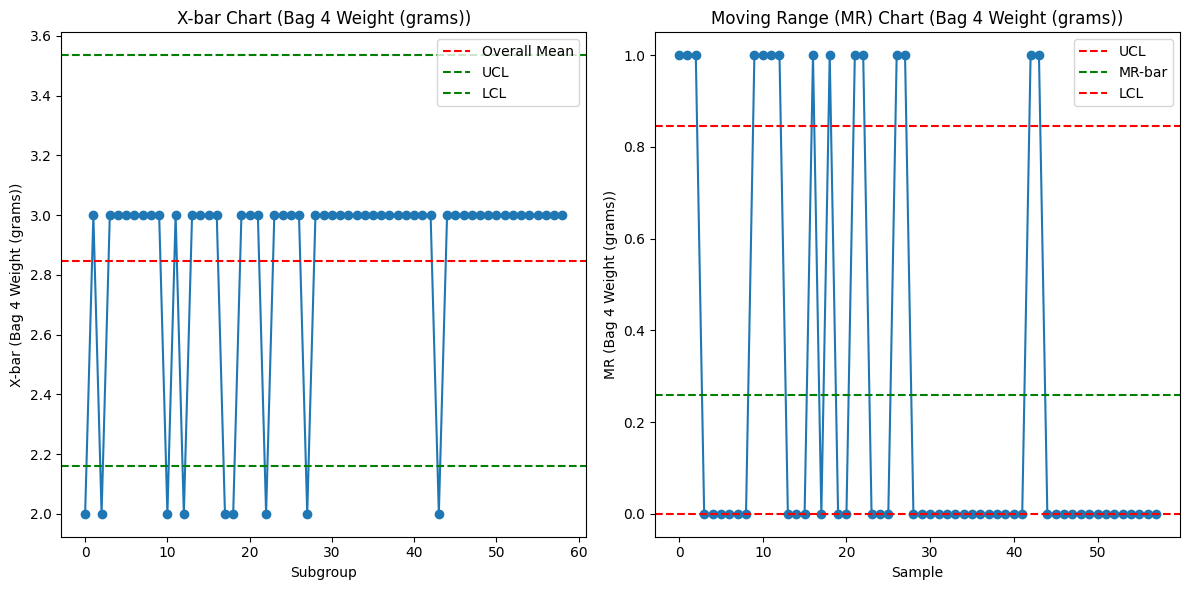

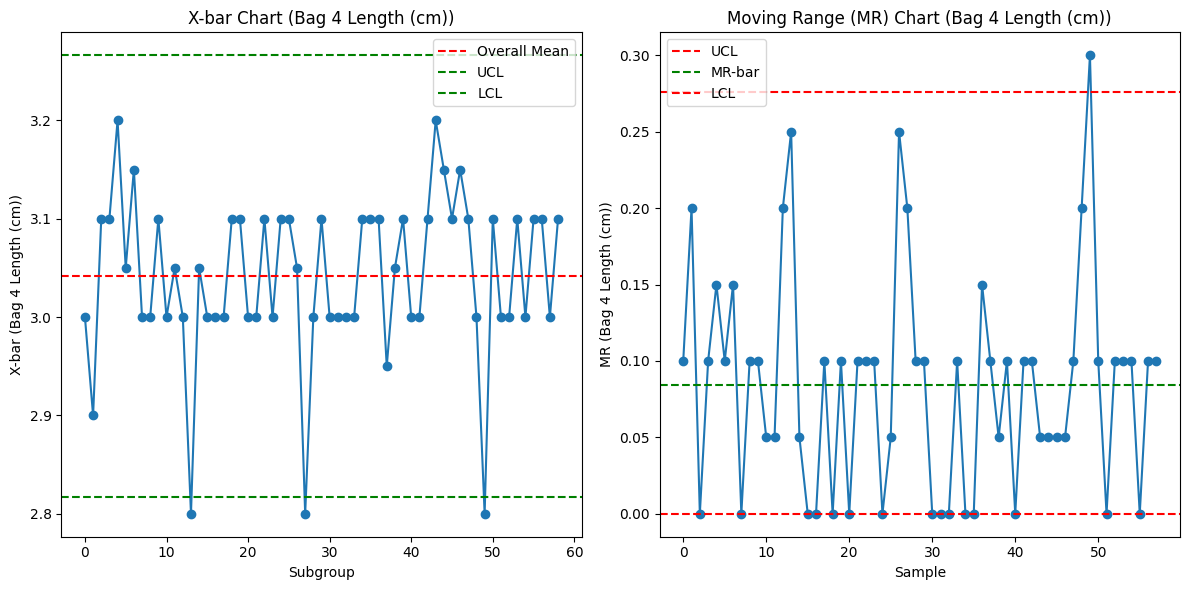

(array([2.8, 2.8, 2.8]),
 array([13, 27, 49]),
 array([0.3]),
 array([50]),
 array([3.  , 2.9 , 3.1 , 3.1 , 3.2 , 3.05, 3.15, 3.  , 3.  , 3.1 , 3.  ,
        3.05, 3.  , 2.8 , 3.05, 3.  , 3.  , 3.  , 3.1 , 3.1 , 3.  , 3.  ,
        3.1 , 3.  , 3.1 , 3.1 , 3.05, 2.8 , 3.  , 3.1 , 3.  , 3.  , 3.  ,
        3.  , 3.1 , 3.1 , 3.1 , 2.95, 3.05, 3.1 , 3.  , 3.  , 3.1 , 3.2 ,
        3.15, 3.1 , 3.15, 3.1 , 3.  , 2.8 , 3.1 , 3.  , 3.  , 3.1 , 3.  ,
        3.1 , 3.1 , 3.  , 3.1 ]),
 np.float64(0.08448275862068969),
 np.float64(3.2662136115497966),
 np.float64(2.81683723590783),
 np.float64(0.2760051724137932),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 4 ##############
plot_IMR_chart(numpy_bag4_weight, 'Bag 4 Weight (grams)')

plot_IMR_chart(numpy_bag4_length, 'Bag 4 Length (cm)')

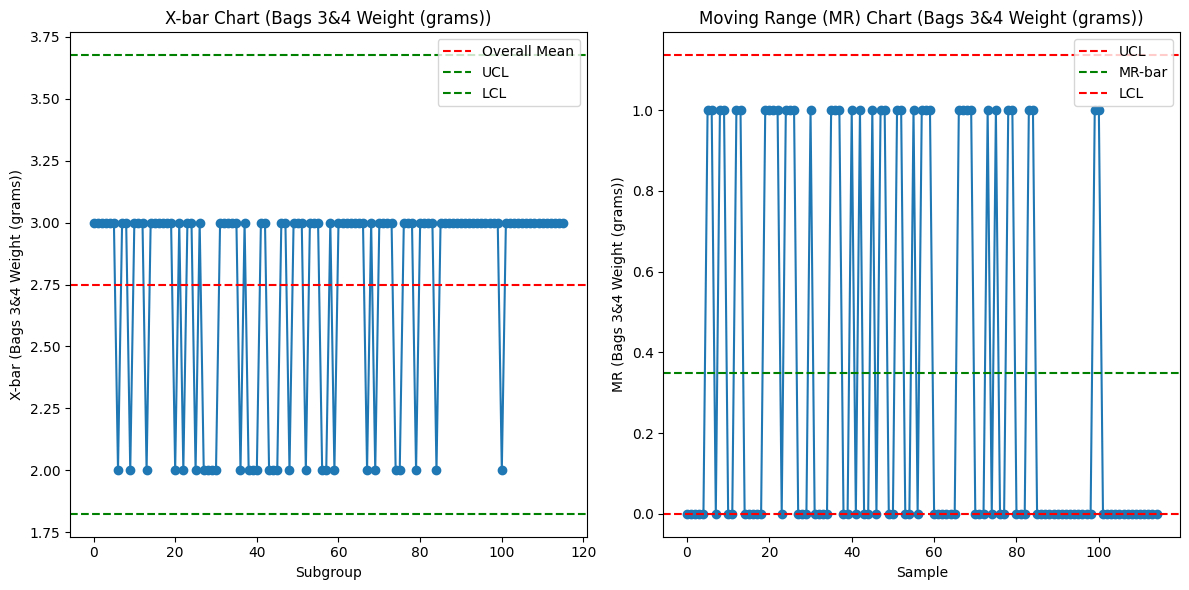

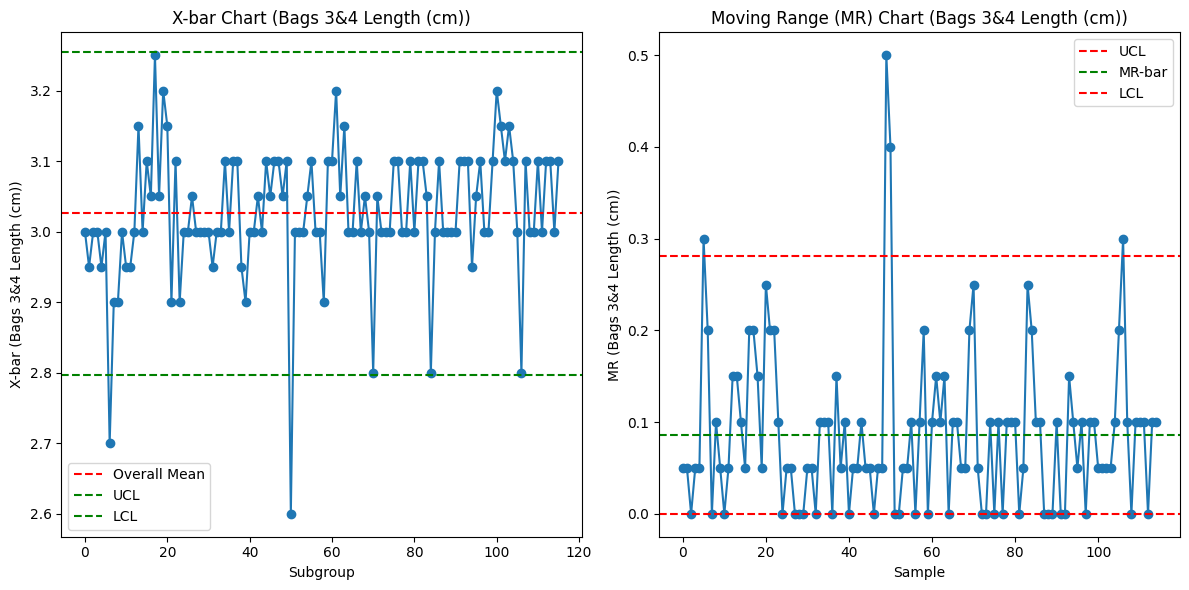

(array([2.7, 2.6]),
 array([ 6, 50]),
 array([0.3, 0.5, 0.4, 0.3]),
 array([  6,  50,  51, 107]),
 array([3.  , 2.95, 3.  , 3.  , 2.95, 3.  , 2.7 , 2.9 , 2.9 , 3.  , 2.95,
        2.95, 3.  , 3.15, 3.  , 3.1 , 3.05, 3.25, 3.05, 3.2 , 3.15, 2.9 ,
        3.1 , 2.9 , 3.  , 3.  , 3.05, 3.  , 3.  , 3.  , 3.  , 2.95, 3.  ,
        3.  , 3.1 , 3.  , 3.1 , 3.1 , 2.95, 2.9 , 3.  , 3.  , 3.05, 3.  ,
        3.1 , 3.05, 3.1 , 3.1 , 3.05, 3.1 , 2.6 , 3.  , 3.  , 3.  , 3.05,
        3.1 , 3.  , 3.  , 2.9 , 3.1 , 3.1 , 3.2 , 3.05, 3.15, 3.  , 3.  ,
        3.1 , 3.  , 3.05, 3.  , 2.8 , 3.05, 3.  , 3.  , 3.  , 3.1 , 3.1 ,
        3.  , 3.  , 3.1 , 3.  , 3.1 , 3.1 , 3.05, 2.8 , 3.  , 3.1 , 3.  ,
        3.  , 3.  , 3.  , 3.1 , 3.1 , 3.1 , 2.95, 3.05, 3.1 , 3.  , 3.  ,
        3.1 , 3.2 , 3.15, 3.1 , 3.15, 3.1 , 3.  , 2.8 , 3.1 , 3.  , 3.  ,
        3.1 , 3.  , 3.1 , 3.1 , 3.  , 3.1 ]),
 np.float64(0.08608695652173914),
 np.float64(3.2552477750486464),
 np.float64(2.7973384318479066),
 np.float64(0.28

In [ ]:
############## FOR JUST BAGS 3 and 4 ##############
plot_IMR_chart(numpy_bag3bag4_weight, 'Bags 3&4 Weight (grams)')

plot_IMR_chart(numpy_bag3bag4_length, 'Bags 3&4 Length (cm)')

## P chart

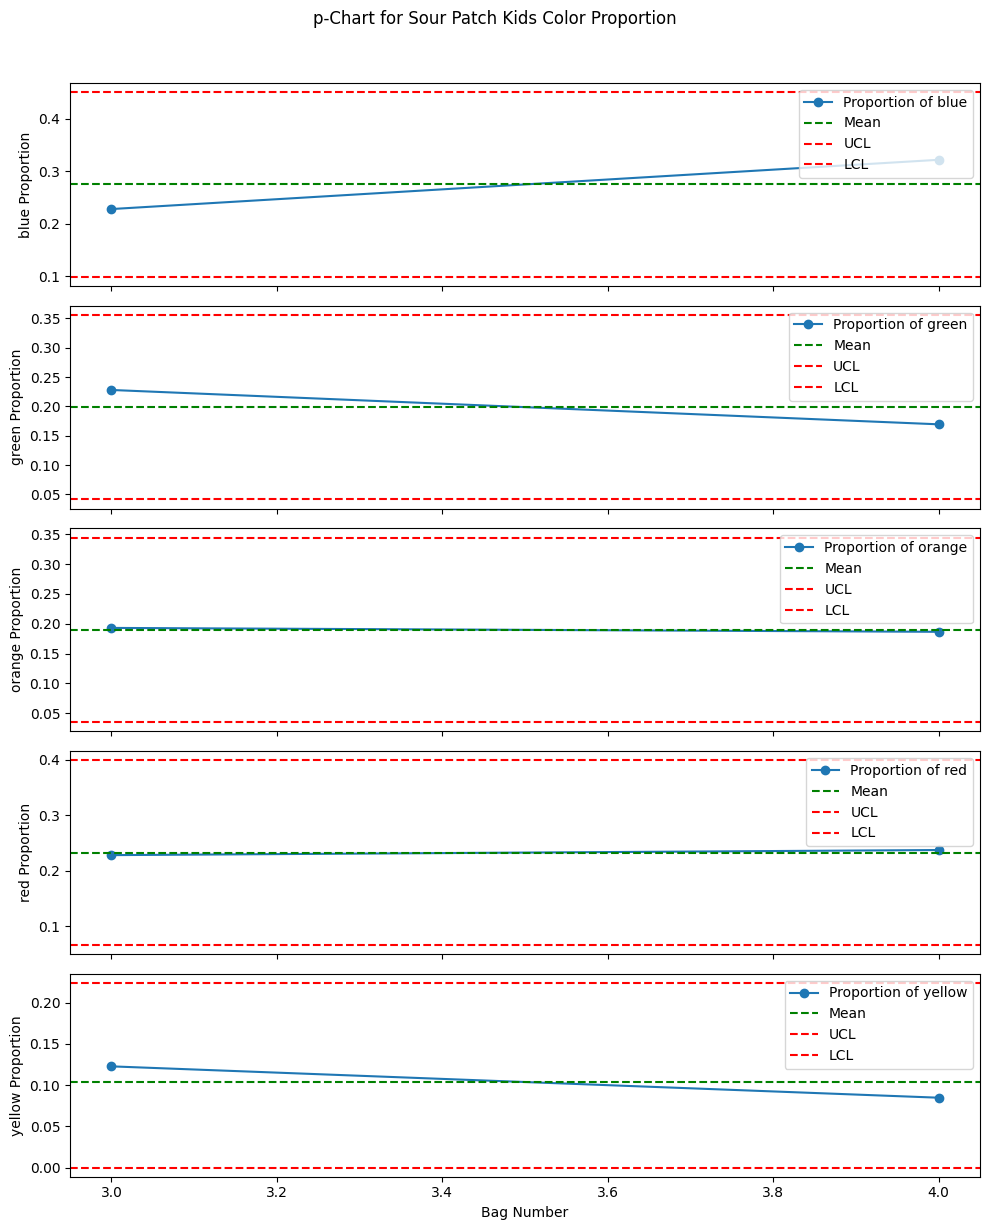

In [ ]:
plot_p_chart_color_proportions(df_bag_3_and_4)

#6.0 Charts and detecting out of control points for bag numbers 5 and 6

In [ ]:
# data
df_bag_5_and_6
df_bag_5 = df_bag_5_and_6[df_bag_5_and_6['Bag Number'] == 5]
df_bag_6 = df_bag_5_and_6[df_bag_5_and_6['Bag Number'] == 6]

numpy_bag5_weight = df_bag_5['Weight (grams)'].values
numpy_bag5_length = df_bag_5['Length (cm)'].values

numpy_bag6_weight = df_bag_6['Weight (grams)'].values
numpy_bag6_length = df_bag_6['Length (cm)'].values

numpy_bag5bag6_weight = np.concatenate((numpy_bag5_weight, numpy_bag6_weight))
numpy_bag5bag6_length = np.concatenate((numpy_bag5_length, numpy_bag6_length))

Note: none of these observations have special causes, so any out of control points are kept

## X bar R chart

In [ ]:
# control limits factors for X-bar chart (A2)
A2 = 1.023
# control limits factors for R chart (D3 and D4)
D3 = 0
D4 = 2.574

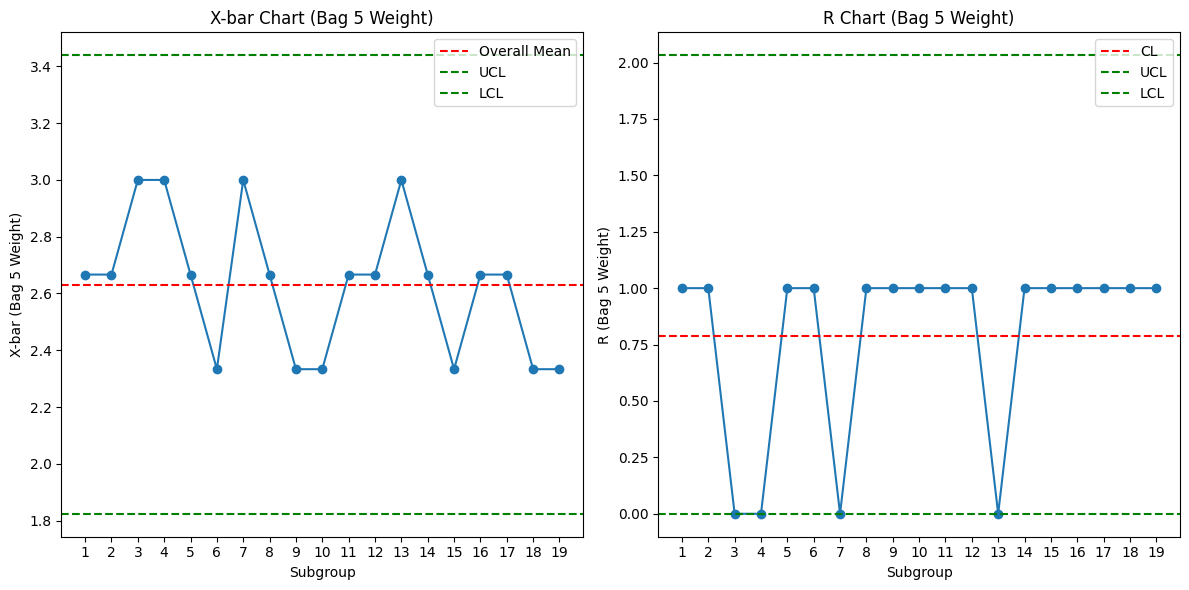

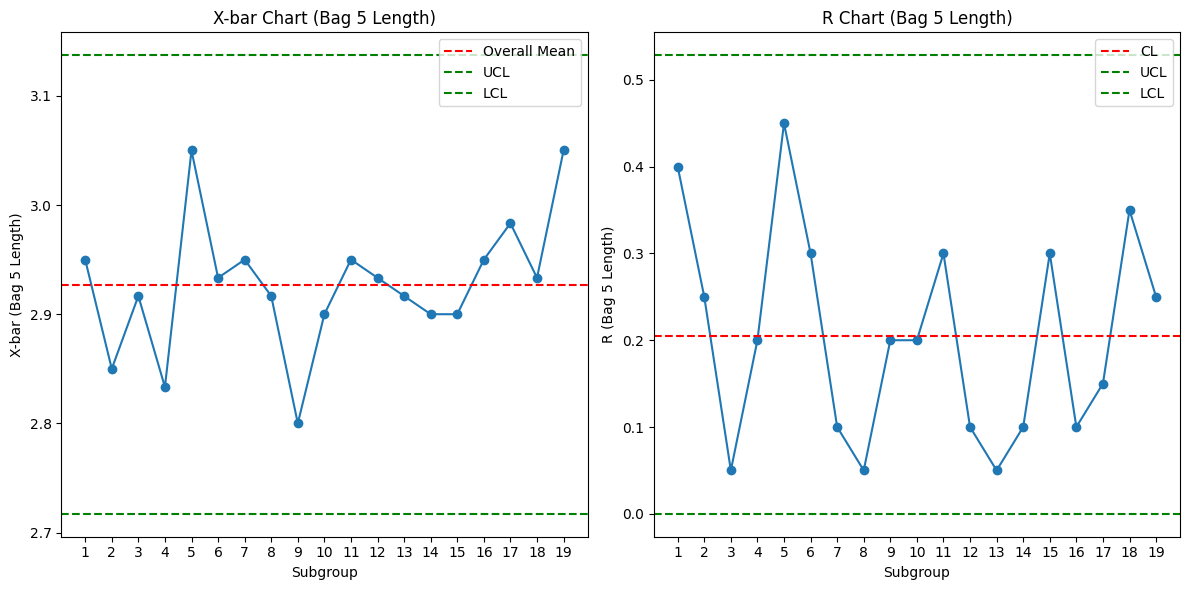

(array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 np.float64(2.9271929824561407),
 np.float64(0.2052631578947369),
 np.float64(3.1371771929824566),
 np.float64(2.717208771929825),
 np.float64(0.5283473684210528),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 5 ##############
plot_xbar_rchart_once(numpy_bag5_weight, 3, A2, D3, D4, "Bag 5 Weight")
# no special causes -- keep OOC points

plot_xbar_rchart_once(numpy_bag5_length, 3, A2, D3, D4, "Bag 5 Length")

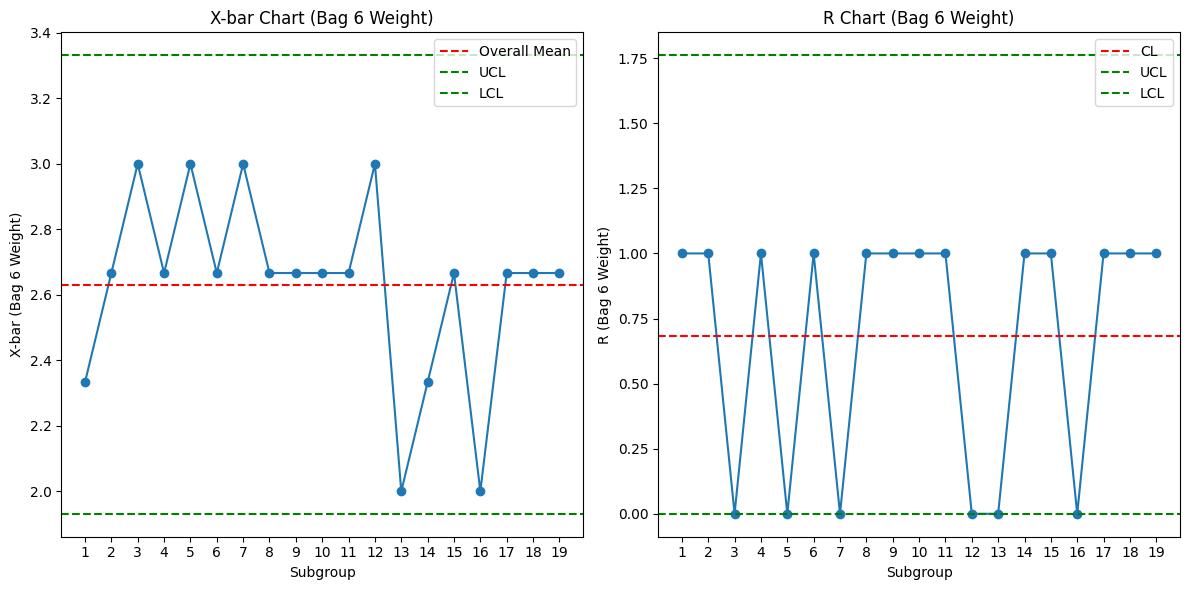

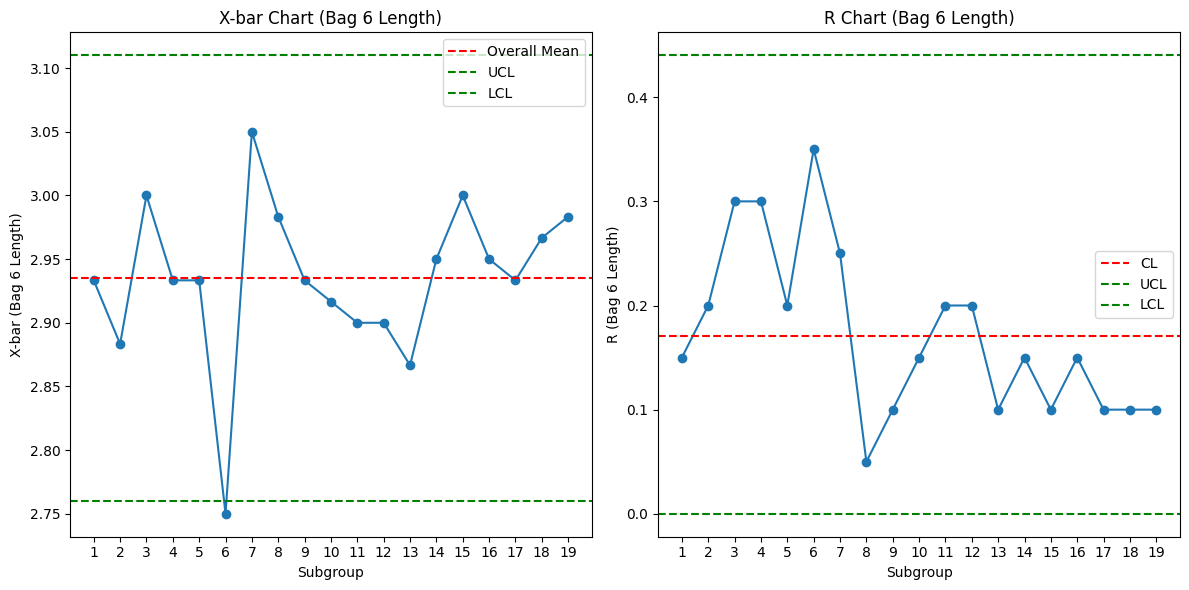

(array([2.95, 2.6 , 2.7 ]),
 array([ 5, 24, 43]),
 array([], dtype=float64),
 array([], dtype=float64),
 np.float64(2.9350877192982456),
 np.float64(0.1710526315789474),
 np.float64(3.1100745614035086),
 np.float64(2.7601008771929827),
 np.float64(0.44028947368421056),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 6 ##############
plot_xbar_rchart_once(numpy_bag6_weight, 3, A2, D3, D4, "Bag 6 Weight")
# no special causes -- keep OOC points

plot_xbar_rchart_once(numpy_bag6_length, 3, A2, D3, D4, "Bag 6 Length")
# no special causes -- keep OOC points


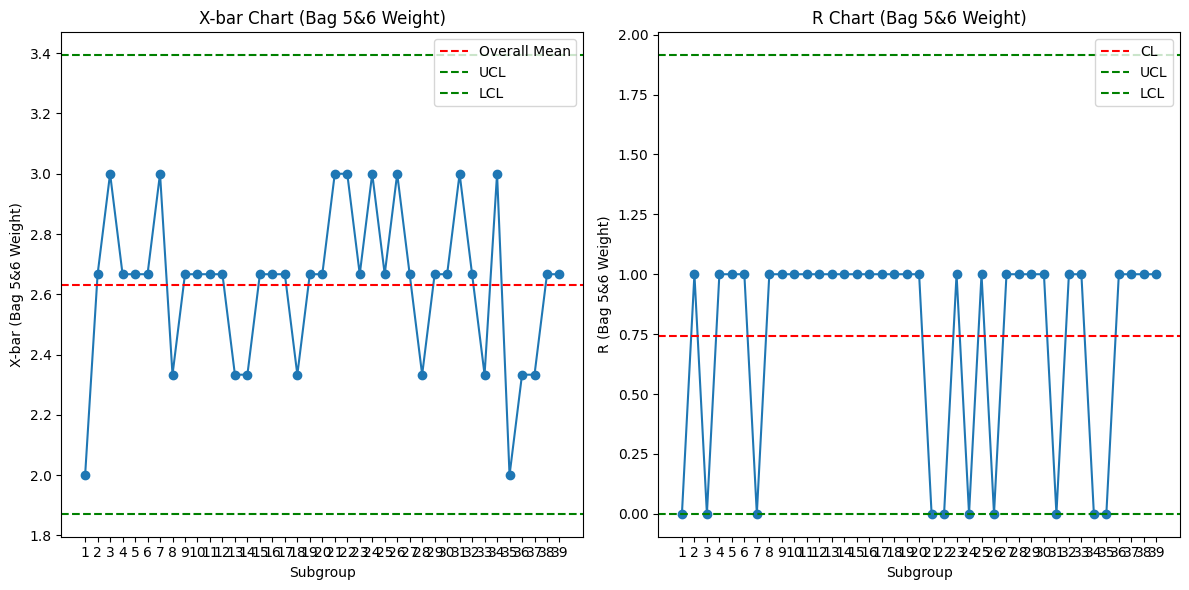

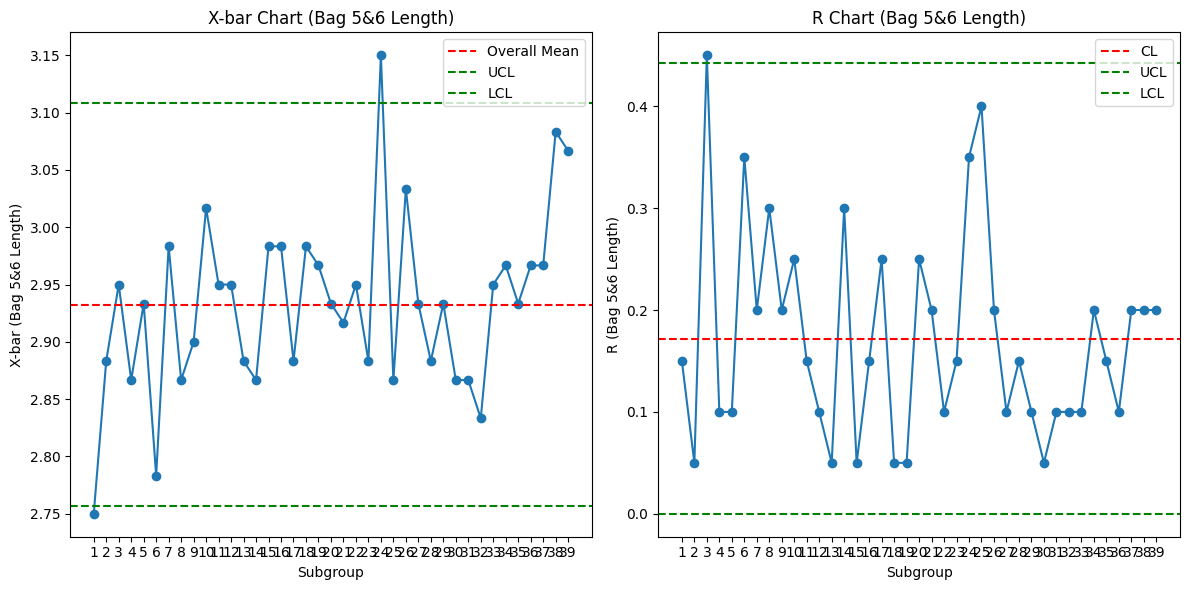

(array([2.7 , 2.7 , 2.85, 3.35, 3.1 , 3.  ]),
 array([ 0,  0, 10, 23, 24, 14]),
 array([2.75, 3.2 ]),
 array([41, 37]),
 np.float64(2.9324786324786327),
 np.float64(0.17179487179487177),
 np.float64(3.1082247863247865),
 np.float64(2.756732478632479),
 np.float64(0.4421999999999999),
 np.float64(0.0))

In [ ]:
############## FOR BOTH BAGS 5 AND 6 ##############
plot_data_5_6 = plot_xbar_rchart_once(numpy_bag5bag6_weight, 3, A2, D3, D4, "Bag 5&6 Weight")

plot_xbar_rchart_once(numpy_bag5bag6_length, 3, A2, D3, D4, "Bag 5&6 Length")

## IMR

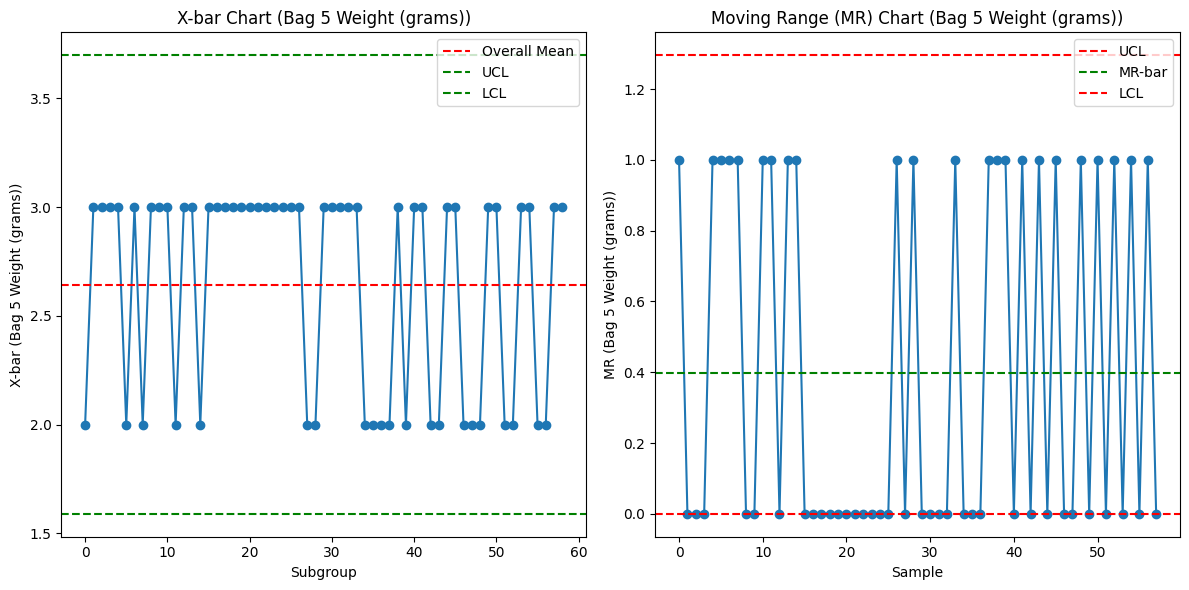

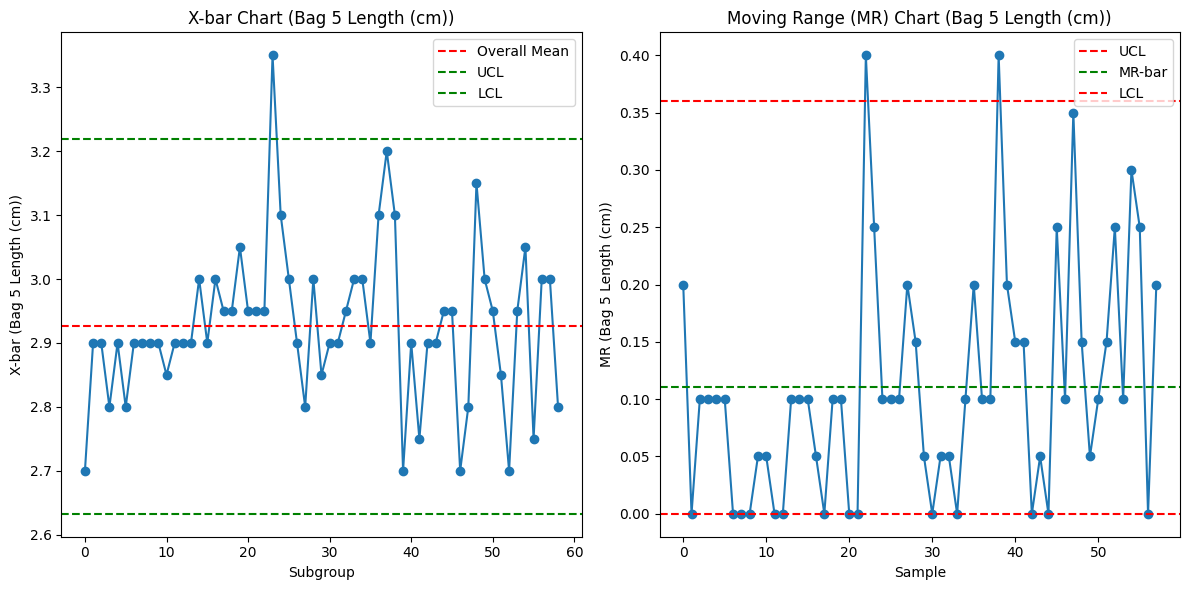

(array([3.35]),
 array([23]),
 array([0.4, 0.4]),
 array([23, 39]),
 array([2.7 , 2.9 , 2.9 , 2.8 , 2.9 , 2.8 , 2.9 , 2.9 , 2.9 , 2.9 , 2.85,
        2.9 , 2.9 , 2.9 , 3.  , 2.9 , 3.  , 2.95, 2.95, 3.05, 2.95, 2.95,
        2.95, 3.35, 3.1 , 3.  , 2.9 , 2.8 , 3.  , 2.85, 2.9 , 2.9 , 2.95,
        3.  , 3.  , 2.9 , 3.1 , 3.2 , 3.1 , 2.7 , 2.9 , 2.75, 2.9 , 2.9 ,
        2.95, 2.95, 2.7 , 2.8 , 3.15, 3.  , 2.95, 2.85, 2.7 , 2.95, 3.05,
        2.75, 3.  , 3.  , 2.8 ]),
 np.float64(0.11034482758620687),
 np.float64(3.219741472574207),
 np.float64(2.632800900307149),
 np.float64(0.3604965517241378),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 5 ##############
plot_IMR_chart(numpy_bag5_weight, 'Bag 5 Weight (grams)')

plot_IMR_chart(numpy_bag5_length, 'Bag 5 Length (cm)')

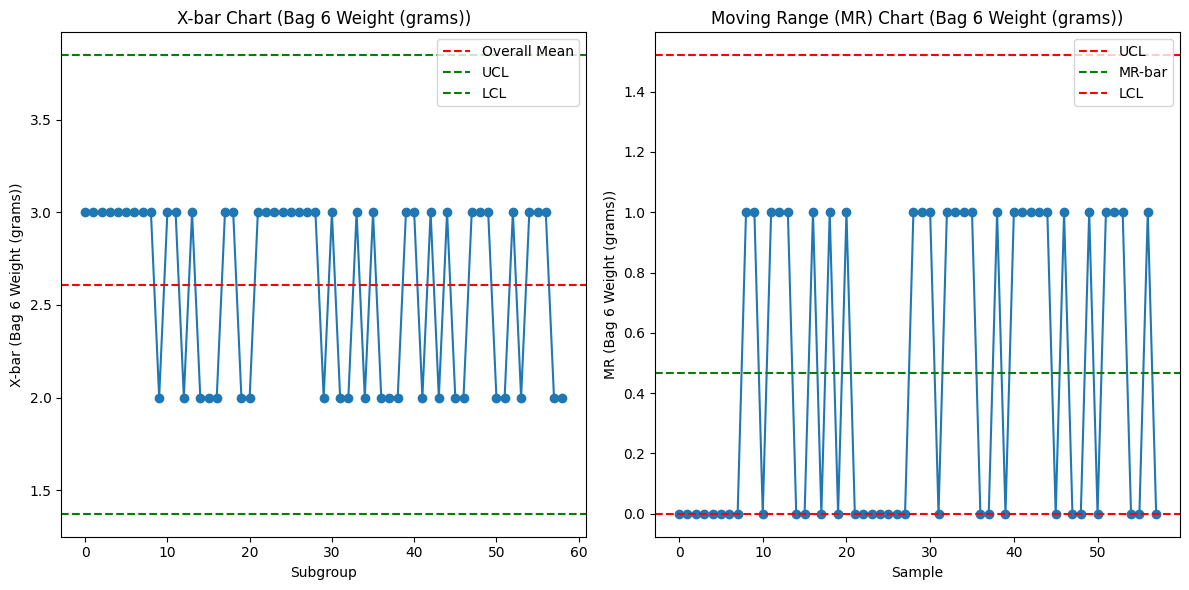

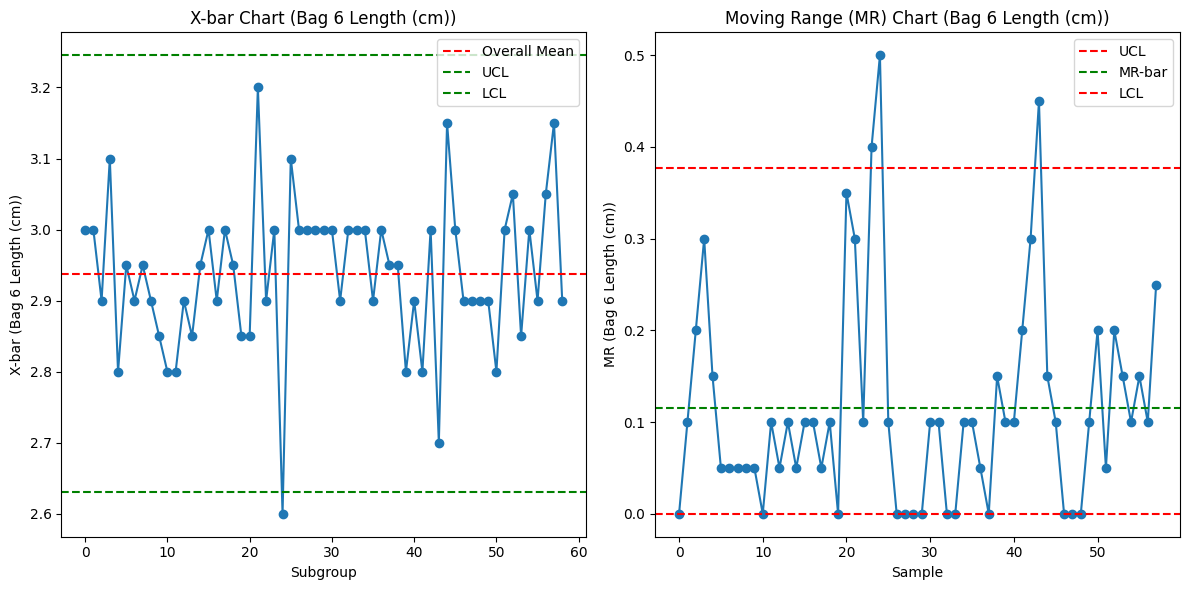

(array([2.6]),
 array([24]),
 array([0.4 , 0.5 , 0.45]),
 array([24, 25, 44]),
 array([3.  , 3.  , 2.9 , 3.1 , 2.8 , 2.95, 2.9 , 2.95, 2.9 , 2.85, 2.8 ,
        2.8 , 2.9 , 2.85, 2.95, 3.  , 2.9 , 3.  , 2.95, 2.85, 2.85, 3.2 ,
        2.9 , 3.  , 2.6 , 3.1 , 3.  , 3.  , 3.  , 3.  , 3.  , 2.9 , 3.  ,
        3.  , 3.  , 2.9 , 3.  , 2.95, 2.95, 2.8 , 2.9 , 2.8 , 3.  , 2.7 ,
        3.15, 3.  , 2.9 , 2.9 , 2.9 , 2.9 , 2.8 , 3.  , 3.05, 2.85, 3.  ,
        2.9 , 3.05, 3.15, 2.9 ]),
 np.float64(0.1155172413793104),
 np.float64(3.245362299016378),
 np.float64(2.630908887424301),
 np.float64(0.37739482758620707),
 np.float64(0.0))

In [ ]:
############## FOR JUST BAG 6 ##############
plot_IMR_chart(numpy_bag6_weight, 'Bag 6 Weight (grams)')

plot_IMR_chart(numpy_bag6_length, 'Bag 6 Length (cm)')

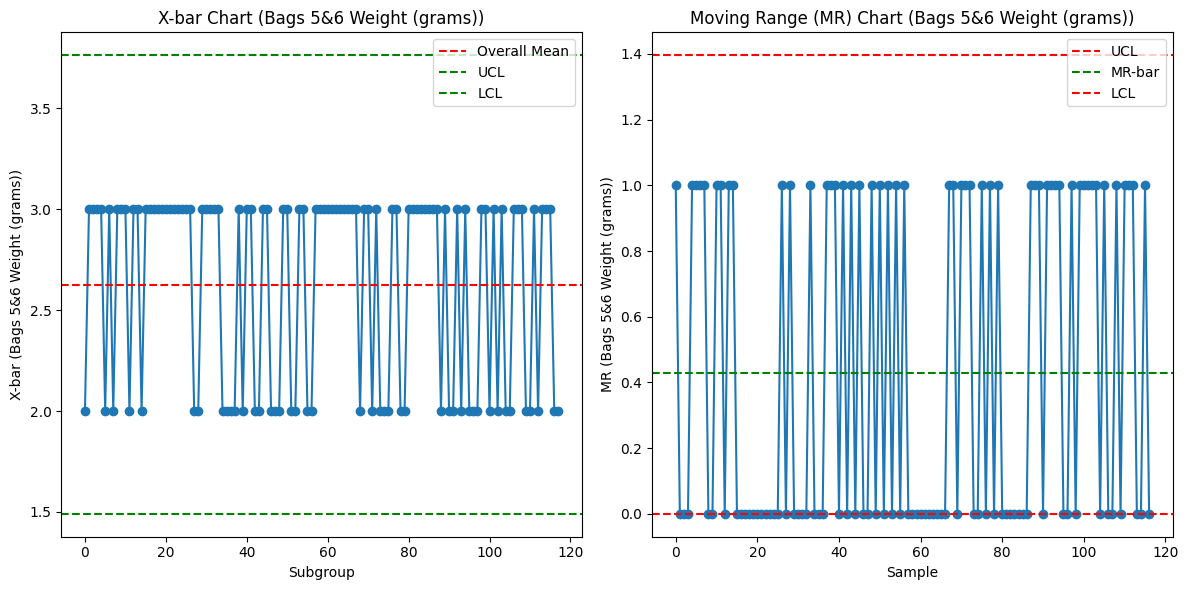

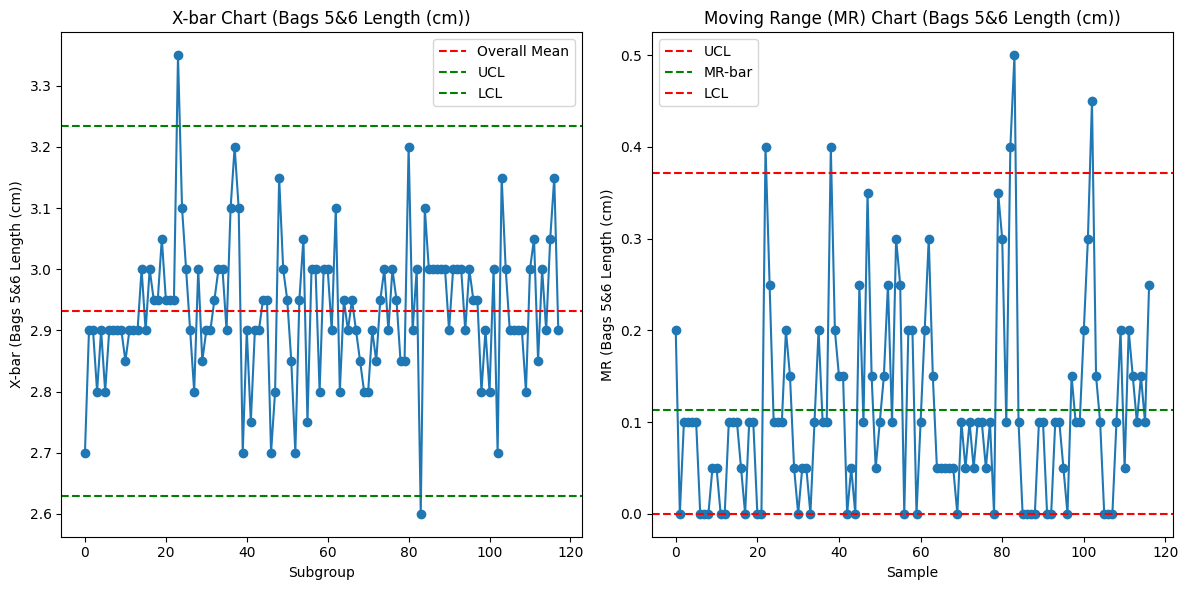

(array([3.35, 2.6 ]),
 array([23, 83]),
 array([0.4 , 0.4 , 0.4 , 0.5 , 0.45]),
 array([ 23,  39,  83,  84, 103]),
 array([2.7 , 2.9 , 2.9 , 2.8 , 2.9 , 2.8 , 2.9 , 2.9 , 2.9 , 2.9 , 2.85,
        2.9 , 2.9 , 2.9 , 3.  , 2.9 , 3.  , 2.95, 2.95, 3.05, 2.95, 2.95,
        2.95, 3.35, 3.1 , 3.  , 2.9 , 2.8 , 3.  , 2.85, 2.9 , 2.9 , 2.95,
        3.  , 3.  , 2.9 , 3.1 , 3.2 , 3.1 , 2.7 , 2.9 , 2.75, 2.9 , 2.9 ,
        2.95, 2.95, 2.7 , 2.8 , 3.15, 3.  , 2.95, 2.85, 2.7 , 2.95, 3.05,
        2.75, 3.  , 3.  , 2.8 , 3.  , 3.  , 2.9 , 3.1 , 2.8 , 2.95, 2.9 ,
        2.95, 2.9 , 2.85, 2.8 , 2.8 , 2.9 , 2.85, 2.95, 3.  , 2.9 , 3.  ,
        2.95, 2.85, 2.85, 3.2 , 2.9 , 3.  , 2.6 , 3.1 , 3.  , 3.  , 3.  ,
        3.  , 3.  , 2.9 , 3.  , 3.  , 3.  , 2.9 , 3.  , 2.95, 2.95, 2.8 ,
        2.9 , 2.8 , 3.  , 2.7 , 3.15, 3.  , 2.9 , 2.9 , 2.9 , 2.9 , 2.8 ,
        3.  , 3.05, 2.85, 3.  , 2.9 , 3.05, 3.15, 2.9 ]),
 np.float64(0.11367521367521369),
 np.float64(3.2345310857752256),
 np.float64(2.629875

In [ ]:
############## FOR JUST BAGS 5 and 6 ##############
plot_IMR_chart(numpy_bag5bag6_weight, 'Bags 5&6 Weight (grams)')

plot_IMR_chart(numpy_bag5bag6_length, 'Bags 5&6 Length (cm)')

## P chart

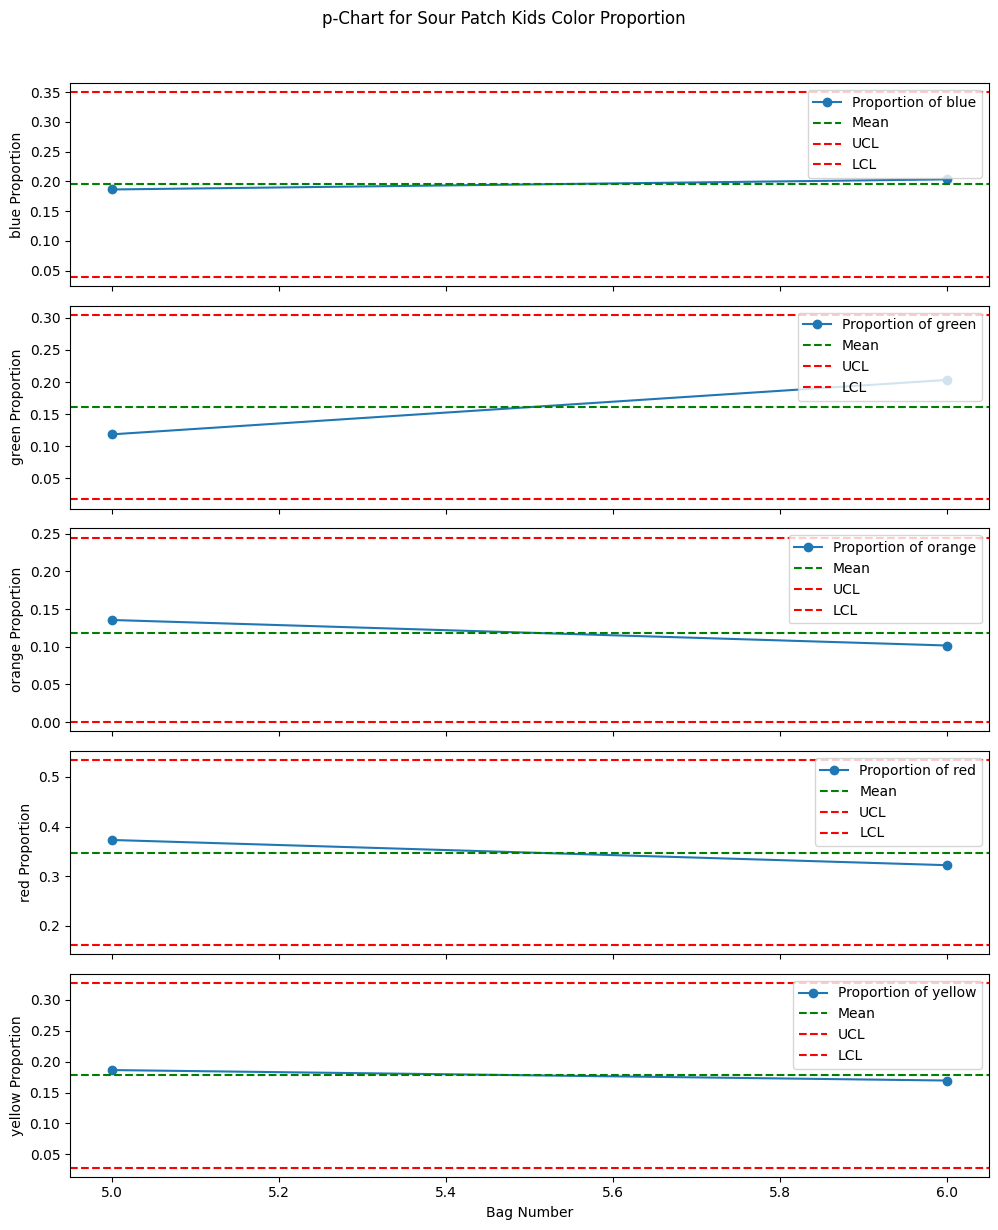

In [ ]:
plot_p_chart_color_proportions(df_bag_5_and_6)

#7.0 Analysis for ALL 6 BAGS

## Charts and detecting out of control points for the COLOUR ATTRIBUTE

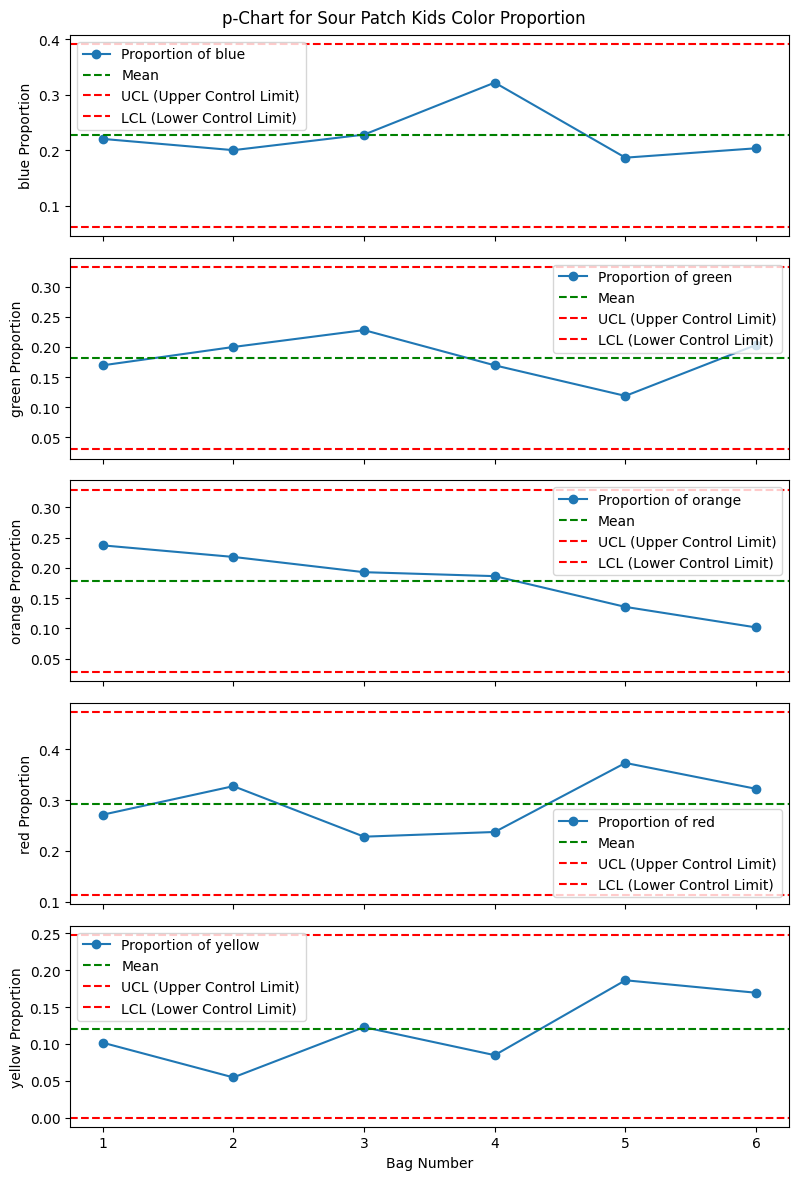

In [ ]:
# calculate total candies per bag
total_per_bag = df_individual.groupby('Bag Number').size()

# calculate color proportions per bag
color_counts = df_individual.groupby(['Bag Number', 'Color']).size().unstack(fill_value=0)
color_proportions = color_counts.div(total_per_bag, axis=0)

# compute overall mean proportion for each color
p_bar = color_proportions.mean()

# compute control limits
n = total_per_bag.mean()  # approximate average sample size
UCL = p_bar + 3 * np.sqrt((p_bar * (1 - p_bar)) / n)
LCL = p_bar - 3 * np.sqrt((p_bar * (1 - p_bar)) / n)
LCL[LCL < 0] = 0  # control limits cannot be negative

# plot the p-chart
fig, axes = plt.subplots(len(color_proportions.columns), 1, figsize=(8, 12), sharex=True)

for i, color in enumerate(color_proportions.columns):
    axes[i].plot(color_proportions.index, color_proportions[color], marker='o', linestyle='-', label=f'Proportion of {color}')
    axes[i].axhline(p_bar[color], color='green', linestyle='--', label='Mean')
    axes[i].axhline(UCL[color], color='red', linestyle='--', label='UCL (Upper Control Limit)')
    axes[i].axhline(LCL[color], color='red', linestyle='--', label='LCL (Lower Control Limit)')

    axes[i].set_ylabel(f'{color} Proportion')
    axes[i].legend()

axes[-1].set_xlabel('Bag Number')
plt.suptitle('p-Chart for Sour Patch Kids Color Proportion')
plt.tight_layout()
plt.show()

## Charts and detecting out of control points for the WEIGHT ATTRIBUTE

### X bar R chart

In [ ]:
numpy_individual_weight = df_individual['Weight (grams)'].values

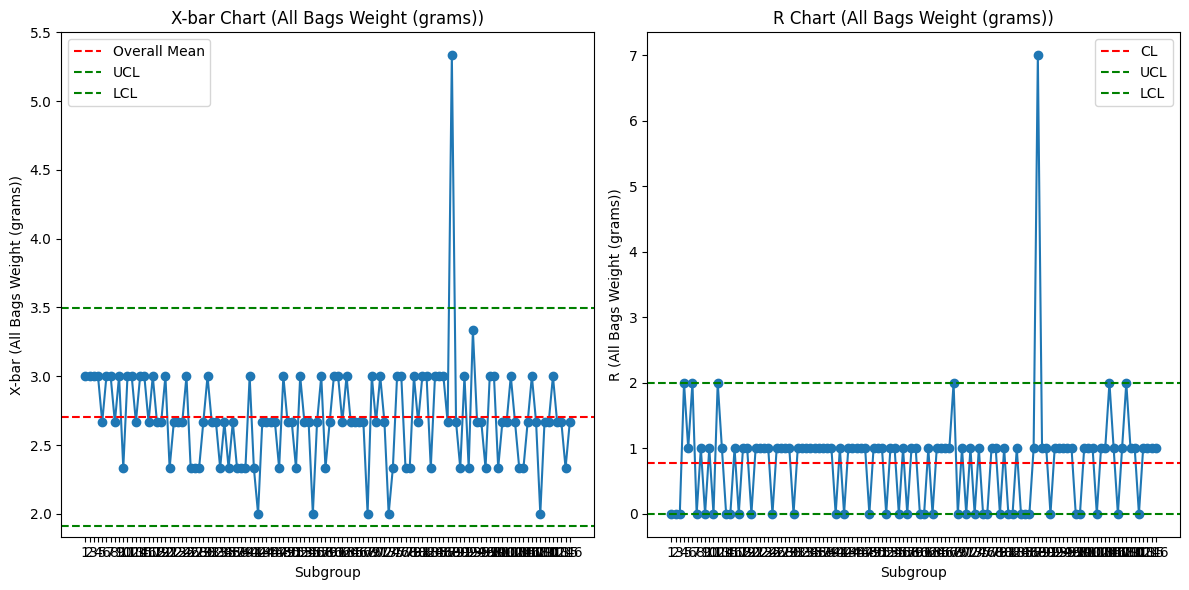

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_points_r, out_of_control_indices_r, x_bar_bar, R_bar, UCL_xbar, LCL_xbar, UCL_R, LCL_R = plot_xbar_rchart_once(numpy_individual_weight, 3, A2, D3, D4, "All Bags Weight (grams)")

In [ ]:
df_individual

numpy_individual_weight, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_points_r,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_r,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_weight
)

Point at index 9 with value 2 has special causes: tiny
Point at index 3 with value 4 has special causes: nan
Point at index 9 with value 2 has special causes: tiny
Point at index 3 with value 4 has special causes: nan
Point at index 9 with value 2 has special causes: tiny
Point at index 3 with value 4 has special causes: nan
Point at index 67 with value 1 has special causes: small
Point at index 0 with value 3 has special causes: nan
Point at index 0 with value 3 has special causes: nan
Point at index 87 with value 10 has special causes: two sourpatches that are connected by what seems like a mold gummy bit
Point at index 67 with value 1 has special causes: small
Point at index 0 with value 3 has special causes: nan
Point at index 67 with value 1 has special causes: small
Point at index 0 with value 3 has special causes: nan


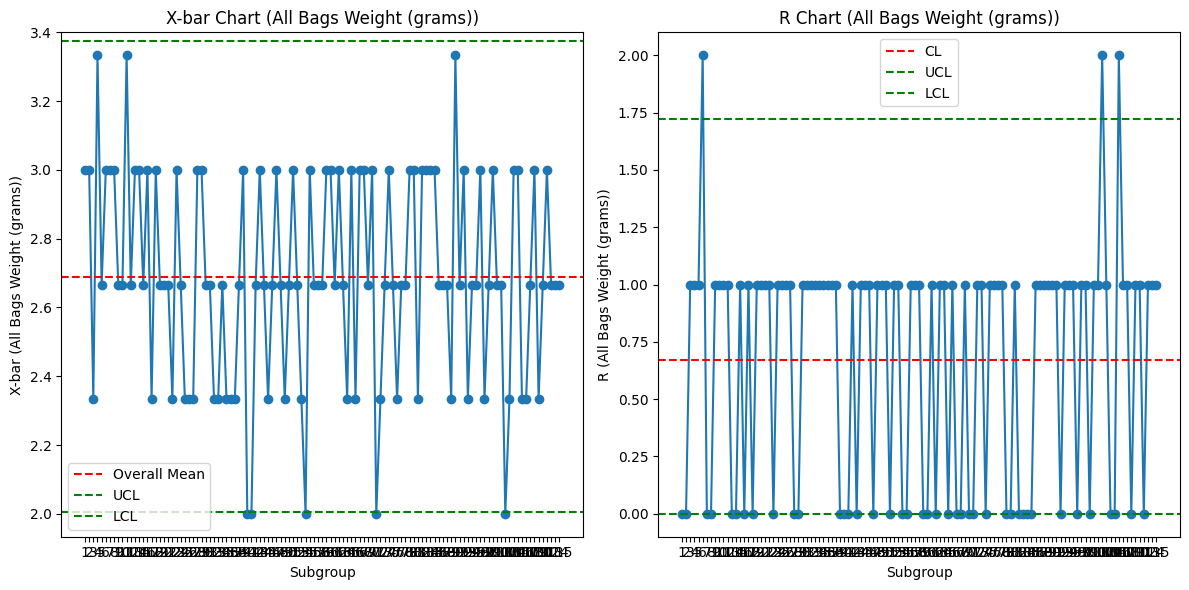

In [ ]:
# make the xbar r chart again
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_points_r, out_of_control_indices_r, x_bar_bar, R_bar, UCL_xbar, LCL_xbar, UCL_R, LCL_R = plot_xbar_rchart_once(numpy_individual_weight, 3, A2, D3, D4, "All Bags Weight (grams)")

### IMR

In [ ]:
# reset the data numpy array
numpy_individual_weight_imr = df_individual['Weight (grams)'].values

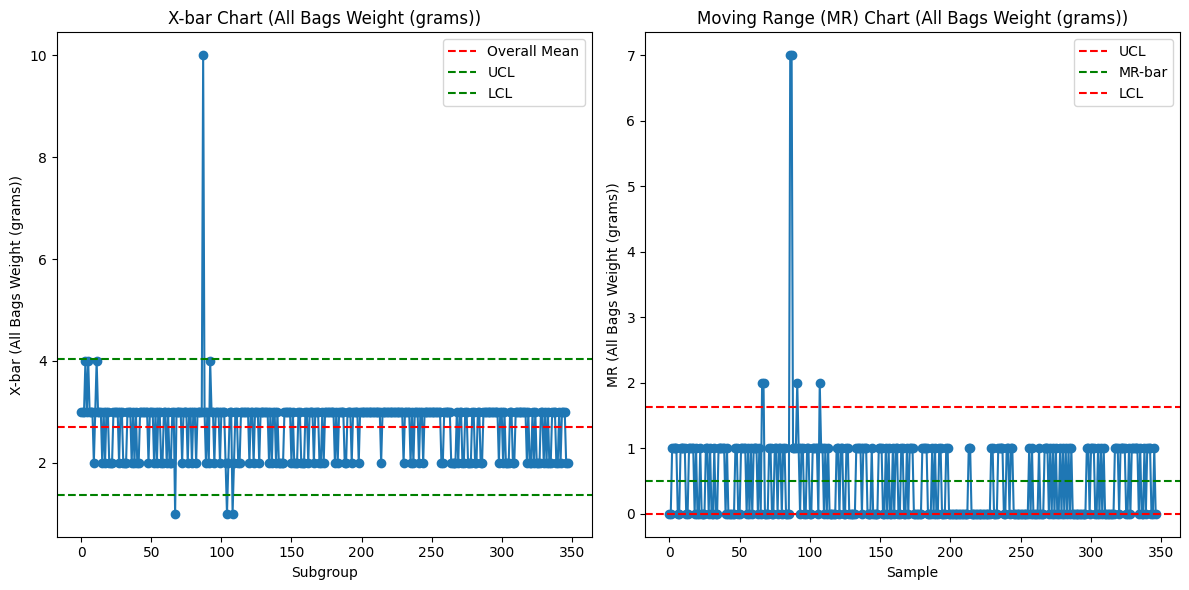

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_weight_imr, 'All Bags Weight (grams)')

In [ ]:
numpy_individual_weight_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_mr_points,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_mr,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_weight_imr
)


Point at index 67 with value 2 has special causes: small
Point at index 68 with value 2 has special causes: nan
Point at index 87 with value 7 has special causes: two sourpatches that are connected by what seems like a mold gummy bit
Point at index 88 with value 7 has special causes: nan
Point at index 92 with value 2 has special causes: thick
Point at index 108 with value 2 has special causes: no definition, rounded, small, skinny, thin


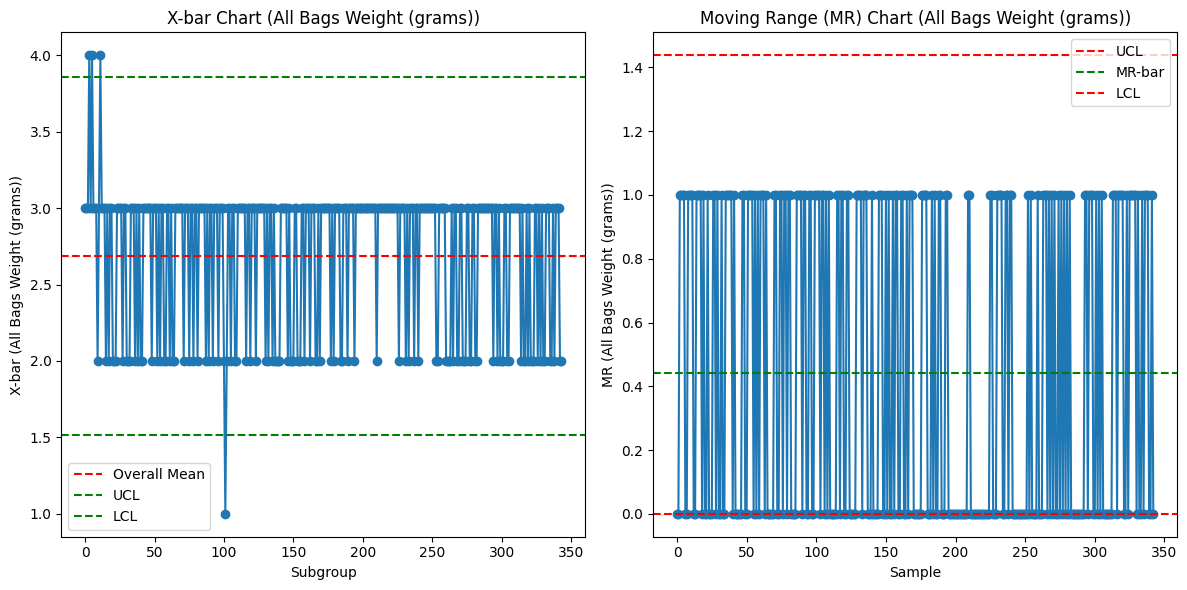

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_weight_imr, 'All Bags Weight (grams)')

In [ ]:
numpy_individual_weight_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_xbar_points,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_xbar,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_weight_imr
)

Point at index 3 with value 4 has special causes: nan
Point at index 5 with value 4 has special causes: nan
Point at index 11 with value 4 has special causes: nan
Point at index 101 with value 1 has special causes: nan


## Charts and detecting out of control points for the LENGTH ATTRIBUTE

In [ ]:
# control limits factors for X-bar chart (A2)
A2 = 1.023
# control limits factors for R chart (D3 and D4)
D3 = 0
D4 = 2.574

In [ ]:
numpy_individual_length = df_individual['Length (cm)'].values

### X bar R chart

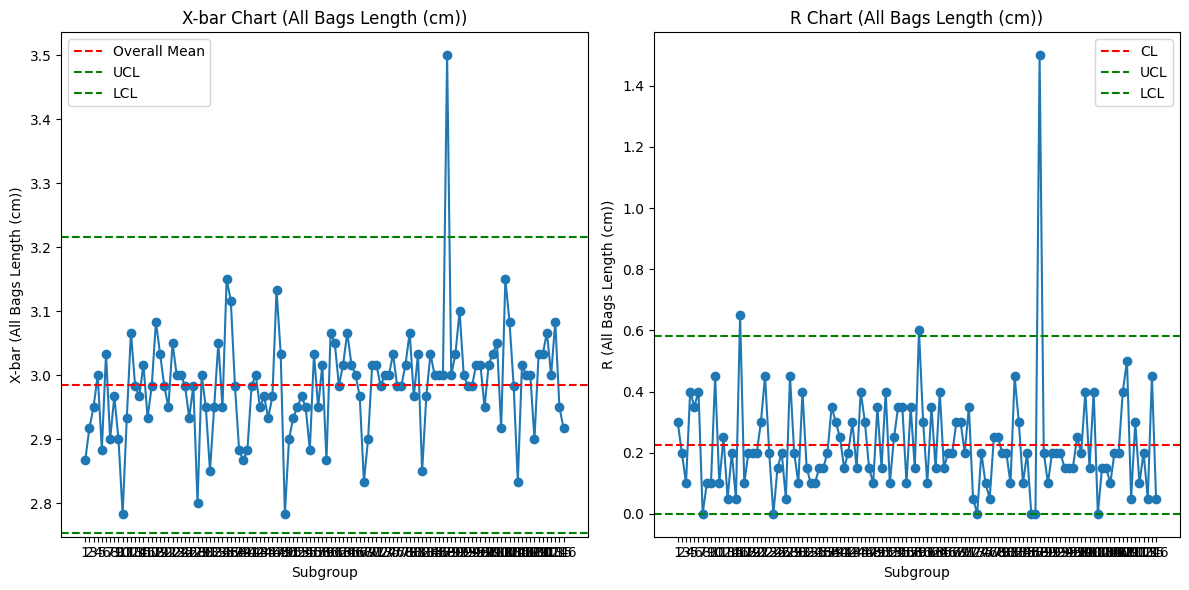

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_points_r, out_of_control_indices_r, x_bar_bar, R_bar, UCL_xbar, LCL_xbar, UCL_R, LCL_R = plot_xbar_rchart_once(numpy_individual_length, 3, A2, D3, D4, "All Bags Length (cm)")

since there are points that are ooc, we will check if they have special causes

In [ ]:
points_w_special_causes = df_individual[df_individual['Deformity'] == True]
points_w_special_causes

,Sample,Bag Number,Color,Weight (grams),Length (cm),Deformity,Notes
9,10,1,red,2,2.50,True,tiny
15,16,1,orange,2,2.60,True,tiny
27,28,1,orange,2,2.55,True,tiny
29,30,1,orange,3,3.00,True,red in the head
30,31,1,orange,2,2.60,True,tiny
37,38,1,green,3,3.05,True,red in the head
38,39,1,orange,2,2.70,True,tiny
54,55,1,red,2,2.65,True,tiny
58,59,1,yellow,2,2.50,True,tiny
64,6,2,red,2,3.00,True,red-orange


In [ ]:
df_individual

numpy_individual_length, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_points_r,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_r,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_length
)

Point at index 15 with value 2.6 has special causes: tiny
Point at index 34 with value 3.25 has special causes: nan
Point at index 9 with value 2.5 has special causes: tiny
Point at index 19 with value 3.1 has special causes: nan
Point at index 2 with value 3.0 has special causes: nan
Point at index 87 with value 4.5 has special causes: two sourpatches that are connected by what seems like a mold gummy bit


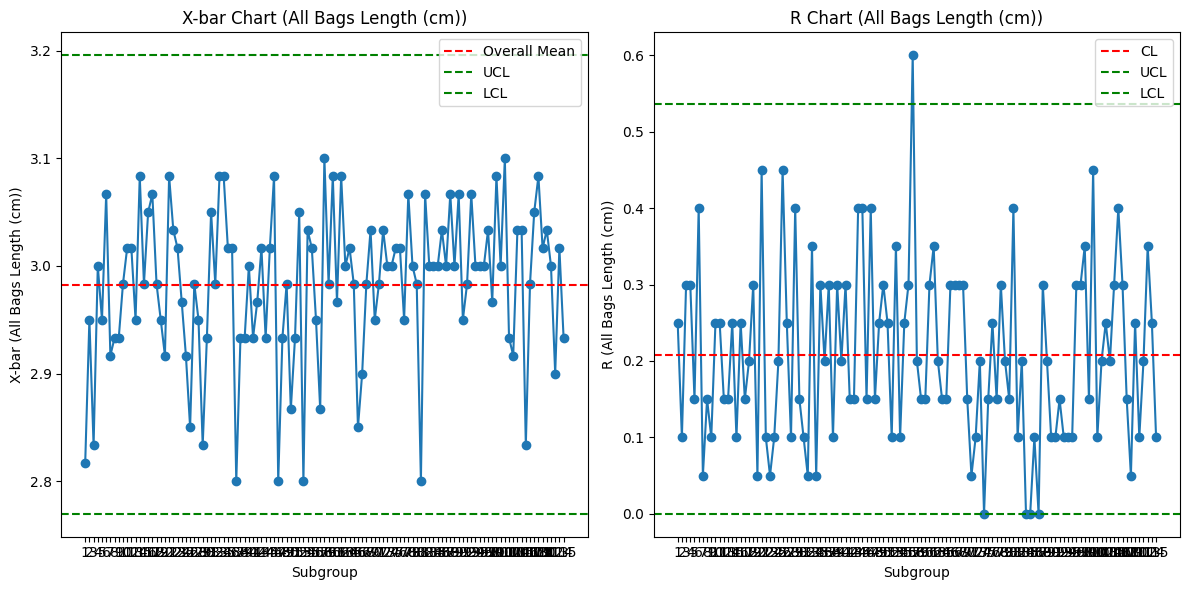

In [ ]:
# make the xbar r chart again
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_points_r, out_of_control_indices_r, x_bar_bar, R_bar, UCL_xbar, LCL_xbar, UCL_R, LCL_R = plot_xbar_rchart_once(numpy_individual_length, 3, A2, D3, D4, "All Bags Length (cm)")

In [ ]:
numpy_individual_length, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_points_r,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_r,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_length
)

Point at index 56 with value 2.5 has special causes: nan
Point at index 17 with value 3.1 has special causes: nan


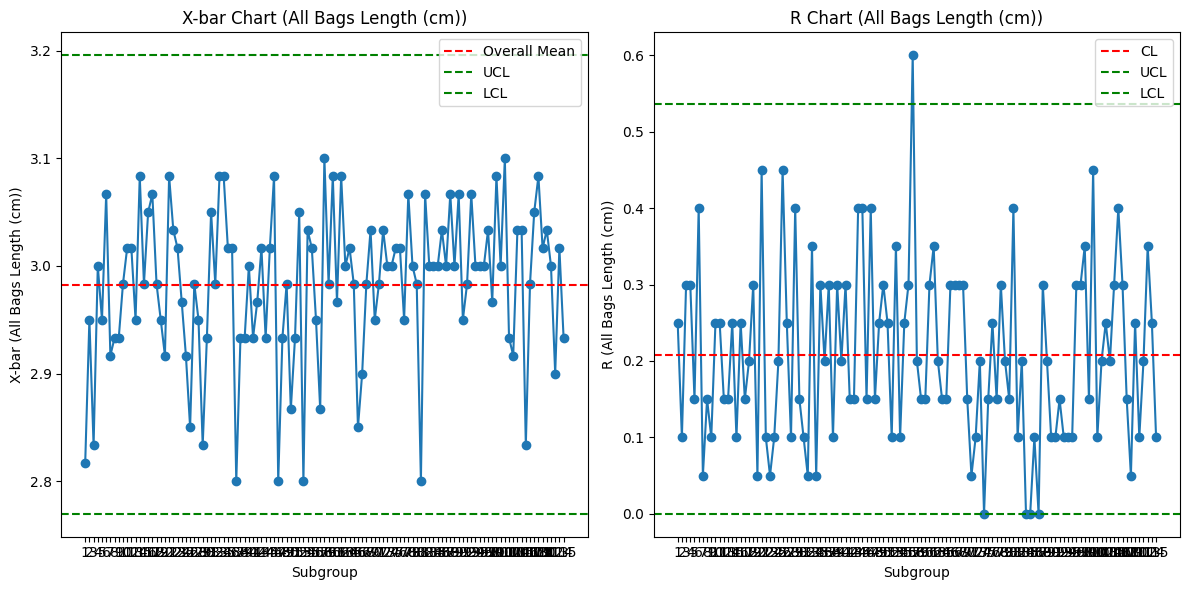

In [ ]:
# make the xbar r chart again
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_points_r, out_of_control_indices_r, x_bar_bar, R_bar, UCL_xbar, LCL_xbar, UCL_R, LCL_R = plot_xbar_rchart_once(numpy_individual_length, 3, A2, D3, D4, "All Bags Length (cm)")

### IMR

In [ ]:
# reset the data numpy array
numpy_individual_length_imr = df_individual['Length (cm)'].values

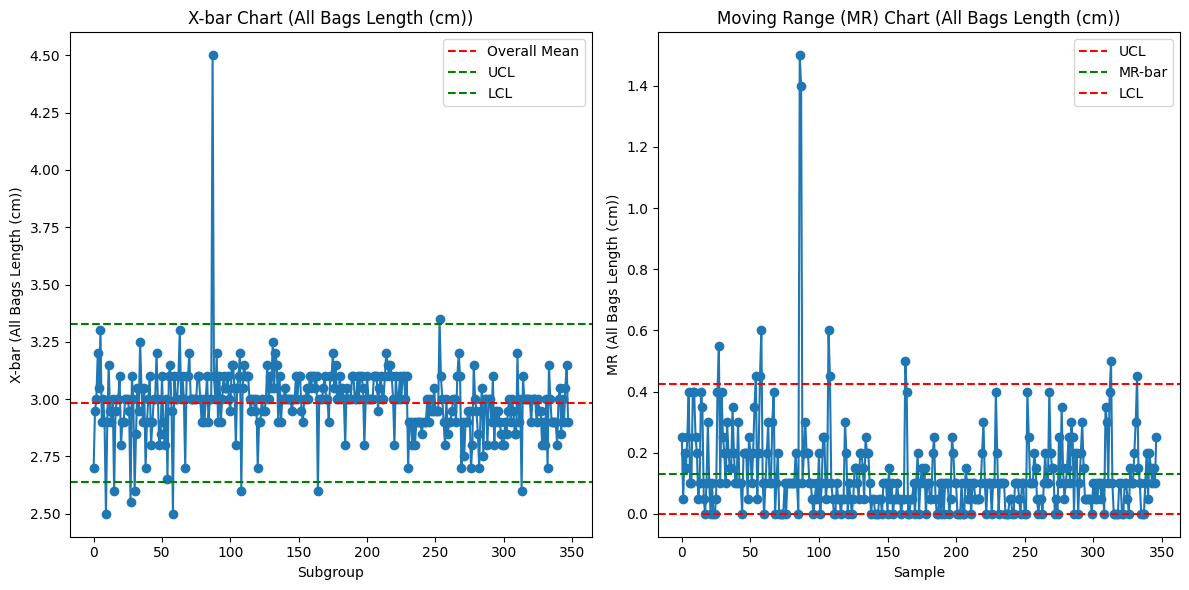

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_length_imr, 'All Bags Length (cm)')

In [ ]:
numpy_individual_length_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_mr_points,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_mr,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_length_imr
)



Point at index 28 with value 0.5500000000000003 has special causes: nan
Point at index 55 with value 0.4500000000000002 has special causes: nan
Point at index 58 with value 0.4500000000000002 has special causes: tiny
Point at index 59 with value 0.6000000000000001 has special causes: nan
Point at index 87 with value 1.5 has special causes: two sourpatches that are connected by what seems like a mold gummy bit
Point at index 88 with value 1.4 has special causes: nan
Point at index 108 with value 0.6000000000000001 has special causes: no definition, rounded, small, skinny, thin
Point at index 109 with value 0.44999999999999973 has special causes: nan
Point at index 164 with value 0.5 has special causes: short
Point at index 314 with value 0.5 has special causes: nan
Point at index 333 with value 0.44999999999999973 has special causes: nan


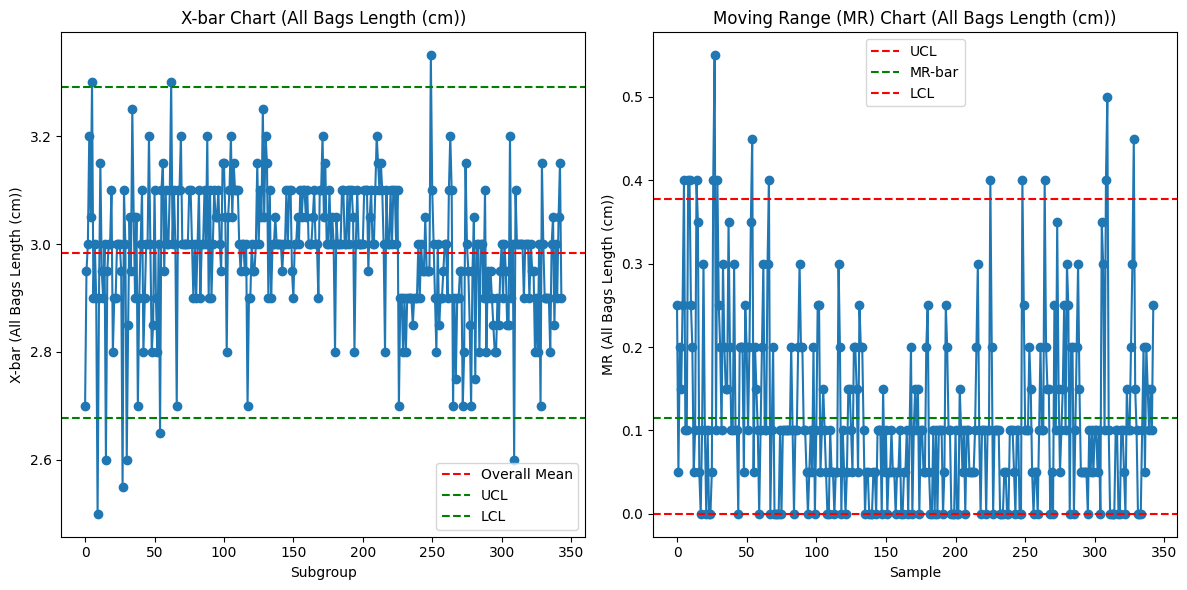

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_length_imr, 'All Bags Length (cm)')

In [ ]:
numpy_individual_length_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_mr_points,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_mr,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_length_imr
)

Point at index 6 with value 0.3999999999999999 has special causes: nan
Point at index 9 with value 0.3999999999999999 has special causes: tiny
Point at index 10 with value 0.3999999999999999 has special causes: nan
Point at index 15 with value 0.3999999999999999 has special causes: tiny
Point at index 27 with value 0.40000000000000036 has special causes: tiny
Point at index 28 with value 0.5500000000000003 has special causes: nan
Point at index 30 with value 0.3999999999999999 has special causes: tiny
Point at index 55 with value 0.4500000000000002 has special causes: nan
Point at index 67 with value 0.3999999999999999 has special causes: small
Point at index 226 with value 0.3999999999999999 has special causes: nan
Point at index 249 with value 0.3999999999999999 has special causes: nan
Point at index 265 with value 0.3999999999999999 has special causes: nan
Point at index 309 with value 0.3999999999999999 has special causes: nan
Point at index 310 with value 0.5 has special causes: n

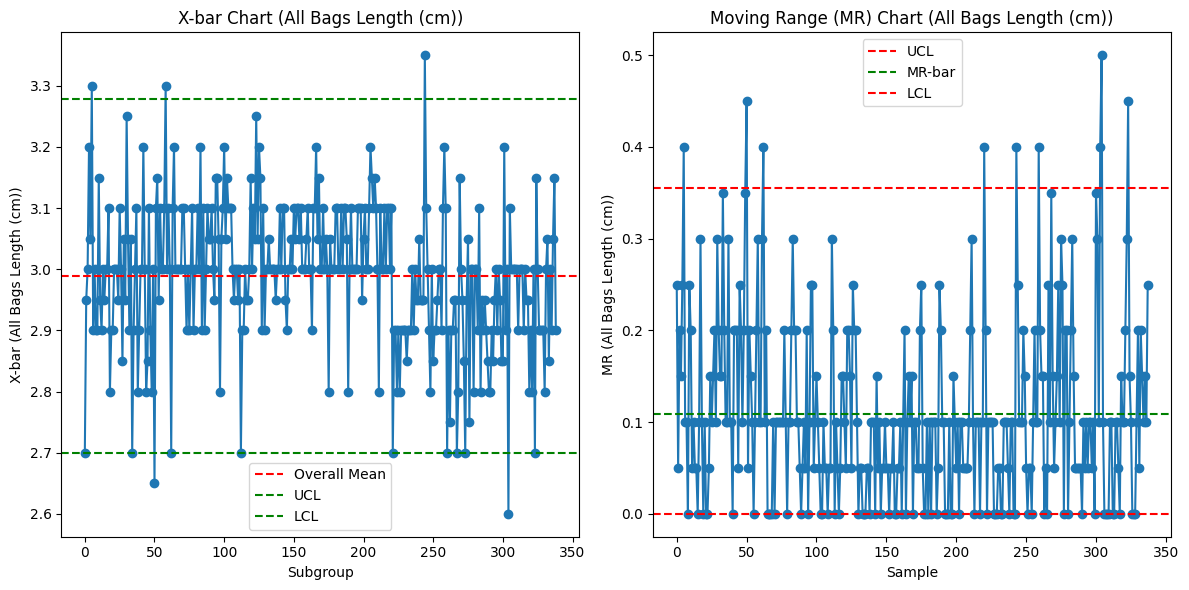

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_length_imr, 'All Bags Length (cm)')

In [ ]:
numpy_individual_length_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_mr_points,  # or out_of_control_xbar_points if you want for X-bar
    out_of_control_indices_mr,  # or out_of_control_indices_xbar if you want for X-bar
    numpy_individual_length_imr
)

Point at index 6 with value 0.3999999999999999 has special causes: nan
Point at index 51 with value 0.4500000000000002 has special causes: nan
Point at index 63 with value 0.3999999999999999 has special causes: nan
Point at index 221 with value 0.3999999999999999 has special causes: nan
Point at index 244 with value 0.3999999999999999 has special causes: nan
Point at index 260 with value 0.3999999999999999 has special causes: nan
Point at index 304 with value 0.3999999999999999 has special causes: nan
Point at index 305 with value 0.5 has special causes: nan
Point at index 324 with value 0.44999999999999973 has special causes: nan


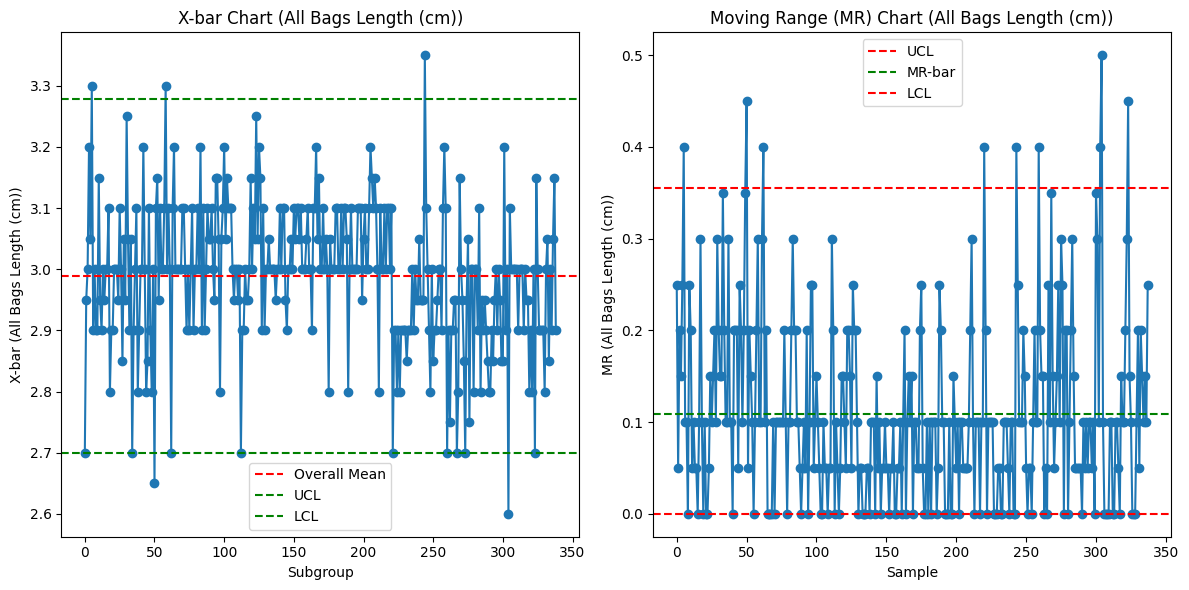

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_length_imr, 'All Bags Length (cm)')

In [ ]:
numpy_individual_length_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_xbar_points,
    out_of_control_indices_xbar,
    numpy_individual_length_imr
)

Point at index 5 with value 3.3 has special causes: nan
Point at index 50 with value 2.65 has special causes: nan
Point at index 58 with value 3.3 has special causes: tiny
Point at index 244 with value 3.35 has special causes: nan
Point at index 304 with value 2.6 has special causes: nan


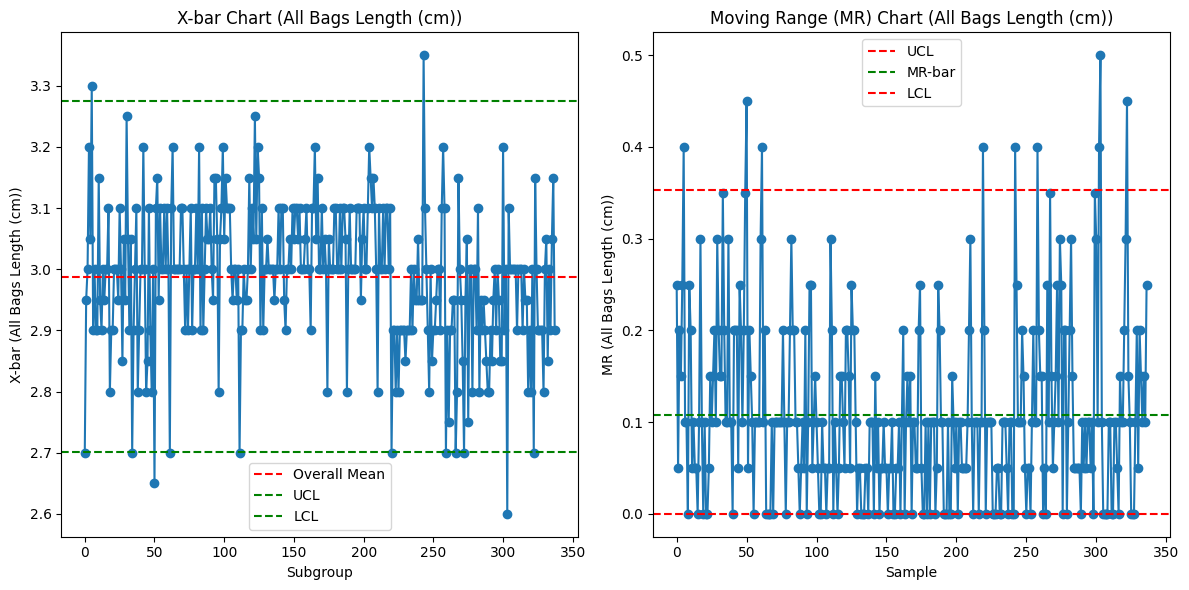

In [ ]:
out_of_control_xbar_points, out_of_control_indices_xbar, out_of_control_mr_points, out_of_control_indices_mr, x_bar, mr_bar, UCL_x, LCL_x, UCL_mr, LCL_mr = plot_IMR_chart(numpy_individual_length_imr, 'All Bags Length (cm)')

In [ ]:
numpy_individual_length_imr, common_causes_index, special_causes_index = handle_out_of_control_points(
    df_individual,
    out_of_control_xbar_points,
    out_of_control_indices_xbar,
    numpy_individual_length_imr
)

Point at index 0 with value 2.7 has special causes: nan
Point at index 5 with value 3.3 has special causes: nan
Point at index 34 with value 2.7 has special causes: nan
Point at index 50 with value 2.65 has special causes: nan
Point at index 61 with value 2.7 has special causes: nan
Point at index 111 with value 2.7 has special causes: nan
Point at index 220 with value 2.7 has special causes: nan
Point at index 243 with value 3.35 has special causes: nan
Point at index 259 with value 2.7 has special causes: nan
Point at index 266 with value 2.7 has special causes: nan
Point at index 272 with value 2.7 has special causes: nan
Point at index 303 with value 2.6 has special causes: nan
Point at index 322 with value 2.7 has special causes: nan


# 8.0 Deformity Analysis

In [ ]:
points_w_special_causes = df_individual[df_individual['Deformity'] == True]
points_w_special_causes

,Sample,Bag Number,Color,Weight (grams),Length (cm),Deformity,Notes
9,10,1,red,2,2.50,True,tiny
15,16,1,orange,2,2.60,True,tiny
27,28,1,orange,2,2.55,True,tiny
29,30,1,orange,3,3.00,True,red in the head
30,31,1,orange,2,2.60,True,tiny
37,38,1,green,3,3.05,True,red in the head
38,39,1,orange,2,2.70,True,tiny
54,55,1,red,2,2.65,True,tiny
58,59,1,yellow,2,2.50,True,tiny
64,6,2,red,2,3.00,True,red-orange


In [ ]:
deformity_dict = {
    "tiny": 0,
    "colour": 0,
    "small/thin/skinny": 0,
    "short": 0
}

for _, row in points_w_special_causes.iterrows():
  note = row['Notes'].lower()  # lowercase helps with consistent matching

  if 'tiny' in note:
      deformity_dict['tiny'] = deformity_dict.get('tiny', 0) + 1
  elif any(color in note for color in ['red', 'orange', 'yellow', 'green', 'blue']):
      deformity_dict['colour'] = deformity_dict.get('colour', 0) + 1
  elif 'small' in note or 'thin' in note or 'skinny' in note:
      deformity_dict['small/thin/skinny'] = deformity_dict.get('small/thin/skinny', 0) + 1
  elif 'short' in note:
      deformity_dict['short'] = deformity_dict.get('short', 0) + 1
  else:
      deformity_dict[note] = deformity_dict.get(note, 0) + 1



In [ ]:
deformity_dict

{'tiny': 7,
 'colour': 3,
 'small/thin/skinny': 5,
 'short': 1,
 'two sourpatches that are connected by what seems like a mold gummy bit': 1,
 'thick': 1,
 'half decapitated, sticky': 1}

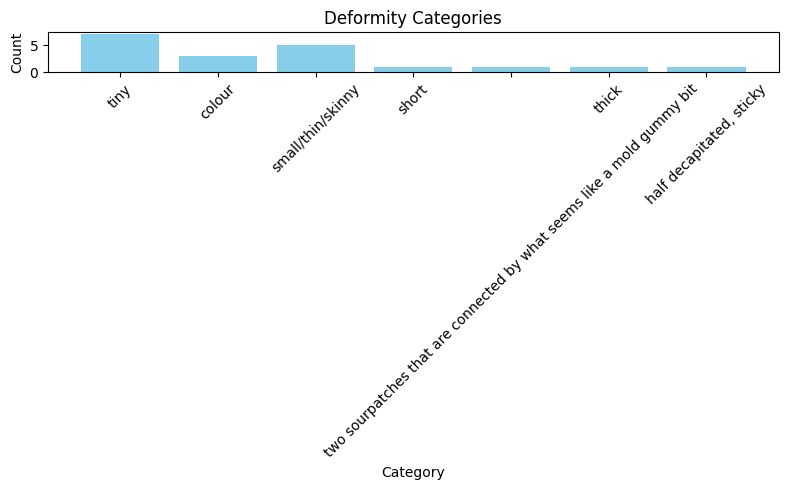

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(deformity_dict.keys(), deformity_dict.values(), color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Deformity Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

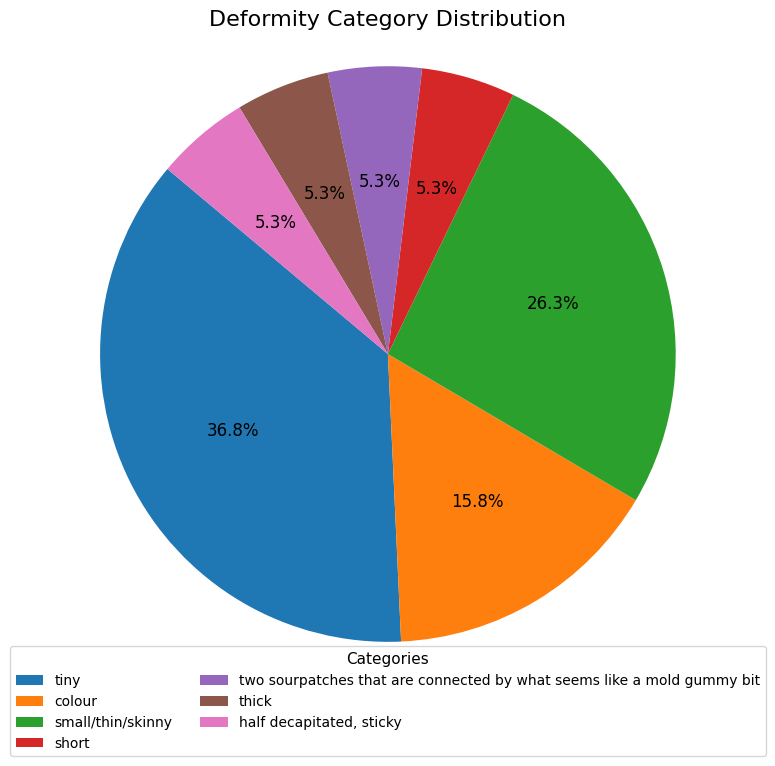

In [ ]:
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    deformity_dict.values(),
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Deformity Category Distribution', fontsize=16, pad=10)
plt.axis('equal')  # keeps it circular

plt.legend(
    deformity_dict.keys(),
    title="Categories",
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(pad=2.0)
plt.show()
